## Section 1: EDA and pre-processing


In [1]:
#-----------------------------------------------------------
# 1. Loading the Data and Understand the data features
#-----------------------------------------------------------

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings

warnings.simplefilter('ignore')

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, LabelEncoder

# Display settings for the dataset
%matplotlib inline
pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows', 120)
sns.set(style = 'whitegrid')

# Features of the original/raw dataset
df = pd.read_csv("diabetic_data_modified.csv")
display(df.shape)
display(df.head())
display(df.info())
display(df.describe())

(101766, 50)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

None

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


## Section 1.1: pre-processing

weight               98564
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
patient_nbr              0
troglitazone             0
glyburide                0
dtype: int64

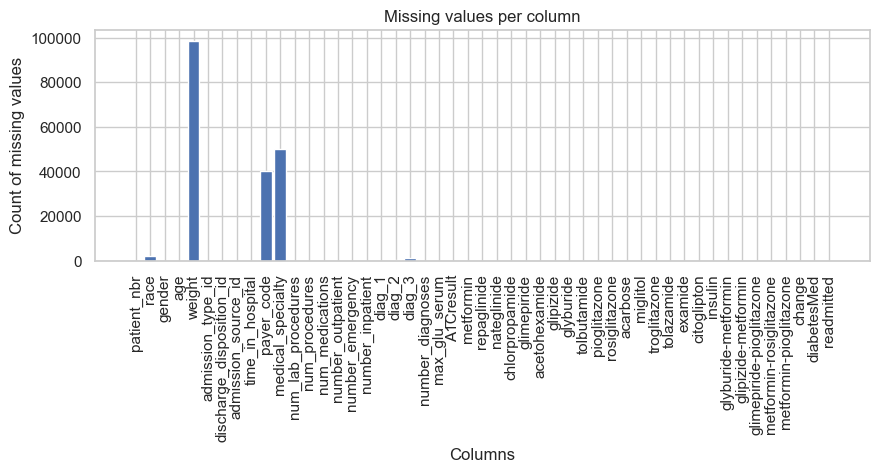

Columns for removal Index(['weight', 'payer_code', 'medical_specialty'], dtype='object')


In [2]:
#------------------------------------------------------------------
# 2. Missing Value Handling and Correcting any other discrepencies
#------------------------------------------------------------------

# 2.1. Handiling Missing Values in columns/features
# Replace special characters with NaN values
df.replace(["?", "#", "*", "NA", "N/A", "NULL", "null", ""], np.nan, inplace=True)
df['max_glu_serum'] = df['max_glu_serum'].fillna('None')
df['A1Cresult'] = df['A1Cresult'].fillna('None')

# Droping the unwanted features like IDs
df.drop(columns=['encounter_id'], inplace = True)

# Evaluating the missing data features
missing_per_col = df.isna().sum()
missing_per_col_sorted = df.isna().sum().sort_values(ascending=False)
display(missing_per_col_sorted.head(10))

# Plot missing values per column
plt.figure(figsize=(10,3))
plt.bar(df.columns.values, missing_per_col.values)
plt.title('Missing values per column')
plt.ylabel('Count of missing values')
plt.xlabel('Columns')
plt.xticks(rotation=90)
plt.show()

# Dropping the columns based on Thresholds
threshold_col = 8000
mask = missing_per_col > threshold_col
columns_tobe_removed=df.columns[mask]
print('Columns for removal', columns_tobe_removed)
df.drop(columns=list(columns_tobe_removed),inplace=True)

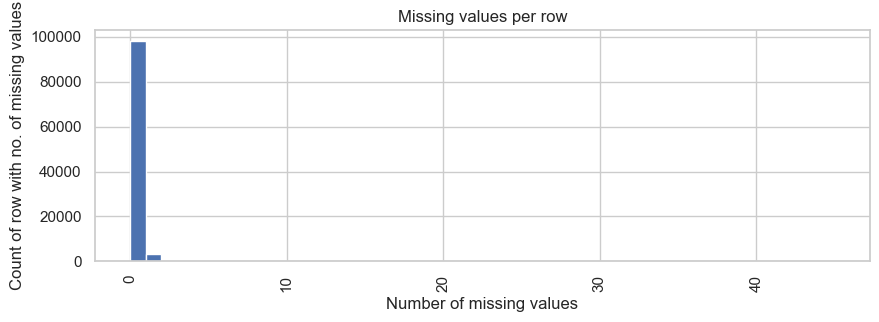

The worst row in the dataset now has 3 missing values 

rest of missing values are: 
 race             2273
diag_3           1423
diag_2            358
diag_1             21
patient_nbr         0
troglitazone        0
glyburide           0
tolbutamide         0
pioglitazone        0
rosiglitazone       0
dtype: int64


In [3]:
#-----------------------------------------------------------
# 2.2. Handiling Missing Values in Rows
#-----------------------------------------------------------
missing_per_row = df.isna().sum(axis=1)

# plotting number of missing values
plt.figure(figsize=(10,3))
plt.hist(missing_per_row.values, bins=range(0,df.shape[1]))
plt.title('Missing values per row')
plt.ylabel('Count of row with no. of missing values')
plt.xlabel('Number of missing values')
plt.xticks(rotation=90)
plt.show()

# select threshold and drop the rows with rows more than the threshold
df.dropna(thresh=(len(df.columns)-5),inplace=True)

# Count missing values per row, then find the highest count
max_missing_in_a_row = df.isna().sum(axis=1).max()
print(f"The worst row in the dataset now has {max_missing_in_a_row} missing values \n")

# finding the rest of the missing values
print('rest of missing values are: \n', df.isna().sum().sort_values(ascending=False).head(10))

In [4]:
#-----------------------------------------------------------
# 3. Data Splitting
#-----------------------------------------------------------

from sklearn.model_selection import train_test_split

display(df.shape)

X = df.drop(columns=['readmitted', 'time_in_hospital'])
y = df[['readmitted', 'time_in_hospital']]

# Split features and targets
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

print(f'Training set size:  X_train={X_train.shape}, y_train={y_train.shape}')
print(f'Test set size:      X_test={X_test.shape}, y_test={y_test.shape}')

# 1. Extract patient_nbr from X_train BEFORE dropping it
groups = X_train['patient_nbr'].values.ravel()

# 2. Drop patient_nbr properly with () and reassignment
X_train = X_train.drop(columns=['patient_nbr'])
X_test = X_test.drop(columns=['patient_nbr'])

print(f'groups length: {len(groups)} (Matches X_train: {len(X_train)})')

(101766, 46)

Training set size:  X_train=(81412, 44), y_train=(81412, 2)
Test set size:      X_test=(20354, 44), y_test=(20354, 2)
groups length: 81412 (Matches X_train: 81412)


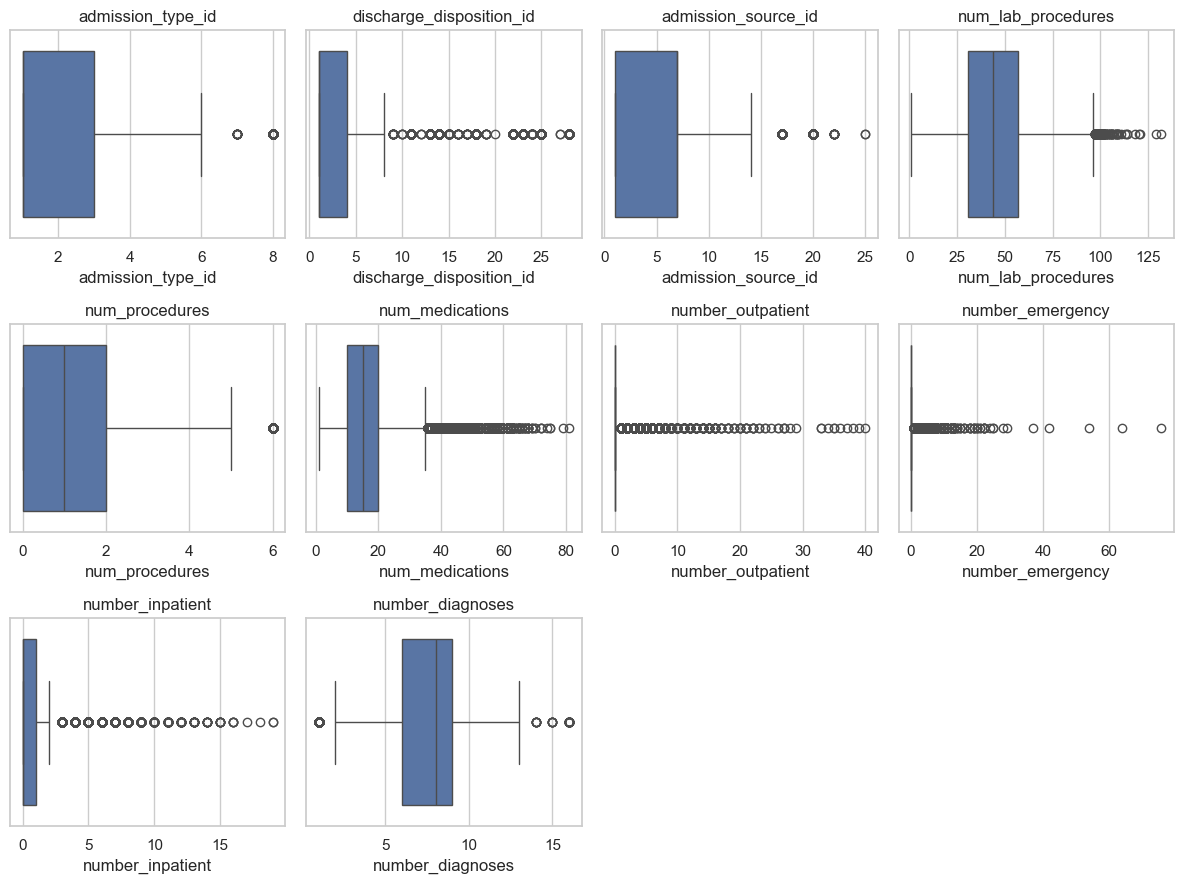

In [5]:
#-----------------------------------------------------------
# 4. Handling the Outliers
#-----------------------------------------------------------
numeric_col = X_train.select_dtypes(include='number').columns

# Box plot to check the outliers
plt.figure(figsize=(12,9))
box_cols = 4
box_rows = int(math.ceil(len(numeric_col)/box_cols))
for i,col in enumerate(numeric_col):
    plt.subplot(box_rows,box_cols,i+1)
    sns.boxplot(x=X_train[col])
    plt.title(col)
plt.tight_layout()    
plt.show()

# ************************************
# Here based on the box plots there is a good data contunity observed across all the plots, hence not removing any outleirs
#******************************************

In [6]:
#-----------------------------------------------------------
# 5. Imputation : Imputation of missing values
#-----------------------------------------------------------
from sklearn.impute import SimpleImputer

#Imputing the missing numeric features with Median
imp_numeric = SimpleImputer(strategy='median') 
numeric_cols = X_train.select_dtypes(include='number').columns
X_train[numeric_cols] = imp_numeric.fit_transform(X_train[numeric_cols])

#Imputing the missing non-numeric features with most-freaquent occuring value/string
imp_non_numeric = SimpleImputer(strategy='most_frequent') 
non_numeric_cols = X_train.select_dtypes(exclude='number').columns
X_train[non_numeric_cols] = imp_non_numeric.fit_transform(X_train[non_numeric_cols])

# Check for any remaining missing values
display('Remaining missing values:', X_train.isna().sum().sort_values(ascending=False).head(10))
display('Remaining missing values:', y_train.isna().sum().sort_values(ascending=False).head(10))

# apply the same fitted imputers to the test set
X_test[numeric_cols] = imp_numeric.transform(X_test[numeric_cols])
X_test[non_numeric_cols] = imp_non_numeric.transform(X_test[non_numeric_cols])


'Remaining missing values:'

race             0
tolazamide       0
glipizide        0
glyburide        0
tolbutamide      0
pioglitazone     0
rosiglitazone    0
acarbose         0
miglitol         0
troglitazone     0
dtype: int64

'Remaining missing values:'

readmitted          0
time_in_hospital    0
dtype: int64

In [7]:
#-----------------------------------------------------------
# 6. Encoding : Categorial variables encoding
#-----------------------------------------------------------

# 6.1. Understanding the categorical features
print(X_train.shape, X_test.shape)

categorical_cols = X_train.select_dtypes(exclude='number').columns

# Loop through each column name to get its unique values
for col in categorical_cols:
    print(f"Unique values in '{col}':", X_train[col].unique())
display(X_train.head(5),X_test.head(5))

(81412, 43) (20354, 43)
Unique values in 'race': ['Caucasian' 'AfricanAmerican' 'Hispanic' 'Other' 'Asian']
Unique values in 'gender': ['Female' 'Male' 'Unknown/Invalid']
Unique values in 'age': ['[70-80)' '[50-60)' '[80-90)' '[40-50)' '[60-70)' '[30-40)' '[10-20)'
 '[90-100)' '[20-30)' '[0-10)' '[170-180)' '[100-120)']
Unique values in 'diag_1': ['276' '427' '599' '331' '38' '414' '491' '537' '780' '428' '596' '227'
 '296' '332' '285' '574' '996' '174' '722' '682' '435' '410' '401' '514'
 '426' '8' '434' '250.8' '724' '295' '338' '250.13' '79' '250.82' '440'
 '592' '404' 'V58' '584' '415' '786' '250.7' '250.2' '560' '250.12' '710'
 '250.4' '275' '198' '562' '648' '402' '998' '530' '486' '250.6' '493'
 '728' '518' '571' '466' '707' '577' '162' '997' 'V57' '715' '250.92'
 '300' '304' 'V54' '459' '250.11' '184' '569' '482' '532' '738' '211'
 '784' '820' '458' '250.03' '831' '726' '411' '821' '153' '250.02' '540'
 '189' '590' '135' '492' '600' '729' '250.1' '451' '431' '824' '453' '403'
 

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
24079,Caucasian,Female,[70-80),1.0,1.0,7.0,48.0,0.0,11.0,0.0,0.0,0.0,276,402,428,9.0,None,Norm,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
98079,Caucasian,Male,[50-60),1.0,1.0,7.0,42.0,0.0,5.0,0.0,0.0,0.0,427,250,278,6.0,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
6237,Caucasian,Male,[80-90),1.0,1.0,7.0,44.0,0.0,10.0,0.0,0.0,0.0,599,788,599,7.0,None,None,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes
72208,Caucasian,Male,[80-90),1.0,3.0,7.0,54.0,0.0,8.0,0.0,0.0,0.0,331,309,331,8.0,None,None,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes
33075,AfricanAmerican,Female,[70-80),1.0,11.0,7.0,35.0,3.0,23.0,0.0,0.0,1.0,38,486,403,8.0,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
35956,Caucasian,Female,[70-80),1.0,1.0,6.0,68.0,0.0,20.0,0.0,0.0,0.0,250.8,599,263,5.0,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes
60927,Caucasian,Male,[50-60),1.0,1.0,1.0,20.0,0.0,7.0,0.0,0.0,0.0,780,427,E941,8.0,None,None,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes
79920,Caucasian,Female,[60-70),3.0,6.0,1.0,21.0,3.0,23.0,1.0,0.0,2.0,715,733,724,7.0,None,None,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes
50078,Caucasian,Male,[30-40),2.0,1.0,1.0,28.0,0.0,19.0,0.0,0.0,1.0,494,277,117,7.0,None,None,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes
44080,AfricanAmerican,Female,[60-70),1.0,2.0,7.0,21.0,0.0,6.0,0.0,0.0,0.0,403,584,428,7.0,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes


In [8]:
#-----------------------------------------------------------
# 6.2. Understanding the categorical features and Encoding
#-----------------------------------------------------------

numeric_col = X_train.select_dtypes(include='number').columns

# 6.2.1..Ordinal encoding

# Defining the columns 
shared_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 
                'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin',
                'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']
ordinal_cols = ['age', 'max_glu_serum', 'A1Cresult'] + shared_cols

# Defining the ranking order
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)', '[100-120)',
             '[170-180)', '[404-500)']
max_glu_serum_order = ['None', 'Norm', '>200', '>300']
A1Cresult_order = ['None', 'Norm', '>7', '>8']
medication_order = ['No', 'Steady', 'Up', 'Down']

master_categories = [age_order, max_glu_serum_order, A1Cresult_order] + ([medication_order] * len(shared_cols))

# Ordinal encoding
encoder = OrdinalEncoder(categories=master_categories, handle_unknown='use_encoded_value', unknown_value=-1)

# Applying the Fit and Transform for train and test data 
X_train[ordinal_cols] = encoder.fit_transform(X_train[ordinal_cols]) 
X_test[ordinal_cols]  = encoder.transform(X_test[ordinal_cols])    

#-----------------------------------------------------------
# 6.2.2..One hot encoding
#-----------------------------------------------------------

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Handling the mixed columns having the categories as mix of 'int + str' and convert to strings
class MixedTypeStringConverter(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return pd.DataFrame(X).astype(str)
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return None
        import numpy as np
        return np.array(input_features)

#  Column groupings
disease_id_cols = ['diag_1', 'diag_2', 'diag_3']
# Standard nominal (unordered) columns 
standard_nominal_cols = ['race','gender', 'change', 'diabetesMed'] 

numeric_ordinal_list = list(numeric_col) + list(ordinal_cols)

# Mixed pipeline
mixed_nominal_pipeline = Pipeline(steps=[
    ('force_string', MixedTypeStringConverter()),
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))])

# To ColumnTransformer 
preprocessor = ColumnTransformer(
    transformers=[
        # Processes mixed columns (int + str) with string conversion
        ('mixed_cat', mixed_nominal_pipeline, disease_id_cols),        
        # Processes standard categories directly without forcing string conversions
        ('standard_cat', OneHotEncoder(sparse_output=False, drop = None, handle_unknown='ignore'),standard_nominal_cols), 
        ('', 'passthrough', numeric_ordinal_list), ],
        remainder='drop', verbose_feature_names_out=True) 

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

# Retrieve the structural column names
encoded_column_names = preprocessor.get_feature_names_out()

# Combining the raw arrays back to dataframe
X_train = pd.DataFrame(X_train_encoded, columns=encoded_column_names, index=X_train.index)
X_test = pd.DataFrame(X_test_encoded, columns=encoded_column_names, index=X_test.index)


print(X_train.info())
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


<class 'pandas.core.frame.DataFrame'>
Index: 81412 entries, 24079 to 15795
Columns: 2214 entries, mixed_cat__diag_1_11 to __metformin-pioglitazone
dtypes: float64(2214)
memory usage: 1.3 GB
None
(81412, 2214) (20354, 2214) (81412, 2) (20354, 2)


In [9]:
#-----------------------------------------------------------
# 7. Handling low variance featutres
#-----------------------------------------------------------

from sklearn.feature_selection import VarianceThreshold 

threshold = 1e-4
selector = VarianceThreshold(threshold=threshold)
selector.fit(X_train)
kept_mask = selector.get_support()
keep_features = X_train.columns[kept_mask]
remove_features = X_train.columns[~kept_mask]
print(remove_features)

# droping the low variance features
X_train.drop(columns=list(remove_features),inplace=True)
X_test.drop(columns=list(remove_features),inplace=True)
print (keep_features)

Index(['mixed_cat__diag_1_11', 'mixed_cat__diag_1_110',
       'mixed_cat__diag_1_115', 'mixed_cat__diag_1_117',
       'mixed_cat__diag_1_131', 'mixed_cat__diag_1_133',
       'mixed_cat__diag_1_136', 'mixed_cat__diag_1_141',
       'mixed_cat__diag_1_142', 'mixed_cat__diag_1_143',
       ...
       'mixed_cat__diag_3_V72', 'mixed_cat__diag_3_V86',
       'standard_cat__gender_Unknown/Invalid', '__acetohexamide',
       '__troglitazone', '__examide', '__citoglipton',
       '__glimepiride-pioglitazone', '__metformin-rosiglitazone',
       '__metformin-pioglitazone'],
      dtype='object', length=1051)
Index(['mixed_cat__diag_1_112', 'mixed_cat__diag_1_135',
       'mixed_cat__diag_1_150', 'mixed_cat__diag_1_151',
       'mixed_cat__diag_1_152', 'mixed_cat__diag_1_153',
       'mixed_cat__diag_1_154', 'mixed_cat__diag_1_155',
       'mixed_cat__diag_1_156', 'mixed_cat__diag_1_157',
       ...
       '__glyburide', '__tolbutamide', '__pioglitazone', '__rosiglitazone',
       '__acarbose

## Section 1.2: FIRST PRE-PROCESSING APPROACH (MinMax scaling)

Considered MinMax Scaling to utlize for clustering and it makes all the features to be within {0 to 1} and comparable across the features. On the other hand, standard scaling assumes gaussian, make an already sparse data further distorted and less comaprable intems of variance. Which may not be ideal for the clustering

In [10]:
#-----------------------------------------------------------
# 8.(A). Numerical Scaling with MinMax Scaler
#-----------------------------------------------------------

display(X_train.info())

# Define the two prefixes you want to search for
target_prefixes = ("mixed_cat__", "standard_cat__")

# Use the ~ symbol to invert the boolean mask (Select columns that DO NOT start with the prefixes)
numeric_ordinal_col = X_train.columns[~X_train.columns.str.startswith(target_prefixes)].tolist()
print("numeric_ordinal_col:", numeric_ordinal_col)

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_MinMax = X_train.copy(); X_test_MinMax = X_test.copy()

X_train_MinMax.loc[:,numeric_ordinal_col] = scaler.fit_transform(X_train_MinMax.loc[:,numeric_ordinal_col])
X_test_MinMax.loc[:,numeric_ordinal_col] = scaler.transform(X_test_MinMax.loc[:,numeric_ordinal_col])

display(X_train_MinMax.head(5),X_test_MinMax.head(5))

<class 'pandas.core.frame.DataFrame'>
Index: 81412 entries, 24079 to 15795
Columns: 1163 entries, mixed_cat__diag_1_112 to __glipizide-metformin
dtypes: float64(1163)
memory usage: 723.0 MB


None

numeric_ordinal_col: ['__admission_type_id', '__discharge_disposition_id', '__admission_source_id', '__num_lab_procedures', '__num_procedures', '__num_medications', '__number_outpatient', '__number_emergency', '__number_inpatient', '__number_diagnoses', '__age', '__max_glu_serum', '__A1Cresult', '__metformin', '__repaglinide', '__nateglinide', '__chlorpropamide', '__glimepiride', '__glipizide', '__glyburide', '__tolbutamide', '__pioglitazone', '__rosiglitazone', '__acarbose', '__miglitol', '__tolazamide', '__insulin', '__glyburide-metformin', '__glipizide-metformin']


,mixed_cat__diag_1_112,mixed_cat__diag_1_135,mixed_cat__diag_1_150,mixed_cat__diag_1_151,mixed_cat__diag_1_152,mixed_cat__diag_1_153,mixed_cat__diag_1_154,mixed_cat__diag_1_155,mixed_cat__diag_1_156,mixed_cat__diag_1_157,mixed_cat__diag_1_158,mixed_cat__diag_1_161,mixed_cat__diag_1_162,mixed_cat__diag_1_171,mixed_cat__diag_1_174,mixed_cat__diag_1_182,mixed_cat__diag_1_183,mixed_cat__diag_1_185,mixed_cat__diag_1_188,mixed_cat__diag_1_189,mixed_cat__diag_1_191,mixed_cat__diag_1_193,mixed_cat__diag_1_196,mixed_cat__diag_1_197,mixed_cat__diag_1_198,mixed_cat__diag_1_199,mixed_cat__diag_1_200,mixed_cat__diag_1_202,mixed_cat__diag_1_203,mixed_cat__diag_1_204,mixed_cat__diag_1_205,mixed_cat__diag_1_211,mixed_cat__diag_1_218,mixed_cat__diag_1_220,mixed_cat__diag_1_225,mixed_cat__diag_1_226,mixed_cat__diag_1_227,mixed_cat__diag_1_233,mixed_cat__diag_1_235,mixed_cat__diag_1_238,...,standard_cat__race_AfricanAmerican,standard_cat__race_Asian,standard_cat__race_Caucasian,standard_cat__race_Hispanic,standard_cat__race_Other,standard_cat__gender_Female,standard_cat__gender_Male,standard_cat__change_Ch,standard_cat__change_No,standard_cat__diabetesMed_No,standard_cat__diabetesMed_Yes,__admission_type_id,__discharge_disposition_id,__admission_source_id,__num_lab_procedures,__num_procedures,__num_medications,__number_outpatient,__number_emergency,__number_inpatient,__number_diagnoses,__age,__max_glu_serum,__A1Cresult,__metformin,__repaglinide,__nateglinide,__chlorpropamide,__glimepiride,__glipizide,__glyburide,__tolbutamide,__pioglitazone,__rosiglitazone,__acarbose,__miglitol,__tolazamide,__insulin,__glyburide-metformin,__glipizide-metformin
24079,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.000000,0.25,0.358779,0.0,0.1250,0.0,0.0,0.000000,0.533333,0.636364,0.0,0.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
98079,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.000000,0.25,0.312977,0.0,0.0500,0.0,0.0,0.000000,0.333333,0.454545,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
6237,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.000000,0.25,0.328244,0.0,0.1125,0.0,0.0,0.000000,0.400000,0.727273,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
72208,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.074074,0.25,0.404580,0.0,0.0875,0.0,0.0,0.000000,0.466667,0.727273,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.0,0.0
33075,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.370370,0.25,0.259542,0.5,0.2750,0.0,0.0,0.052632,0.466667,0.636364,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0


,mixed_cat__diag_1_112,mixed_cat__diag_1_135,mixed_cat__diag_1_150,mixed_cat__diag_1_151,mixed_cat__diag_1_152,mixed_cat__diag_1_153,mixed_cat__diag_1_154,mixed_cat__diag_1_155,mixed_cat__diag_1_156,mixed_cat__diag_1_157,mixed_cat__diag_1_158,mixed_cat__diag_1_161,mixed_cat__diag_1_162,mixed_cat__diag_1_171,mixed_cat__diag_1_174,mixed_cat__diag_1_182,mixed_cat__diag_1_183,mixed_cat__diag_1_185,mixed_cat__diag_1_188,mixed_cat__diag_1_189,mixed_cat__diag_1_191,mixed_cat__diag_1_193,mixed_cat__diag_1_196,mixed_cat__diag_1_197,mixed_cat__diag_1_198,mixed_cat__diag_1_199,mixed_cat__diag_1_200,mixed_cat__diag_1_202,mixed_cat__diag_1_203,mixed_cat__diag_1_204,mixed_cat__diag_1_205,mixed_cat__diag_1_211,mixed_cat__diag_1_218,mixed_cat__diag_1_220,mixed_cat__diag_1_225,mixed_cat__diag_1_226,mixed_cat__diag_1_227,mixed_cat__diag_1_233,mixed_cat__diag_1_235,mixed_cat__diag_1_238,...,standard_cat__race_AfricanAmerican,standard_cat__race_Asian,standard_cat__race_Caucasian,standard_cat__race_Hispanic,standard_cat__race_Other,standard_cat__gender_Female,standard_cat__gender_Male,standard_cat__change_Ch,standard_cat__change_No,standard_cat__diabetesMed_No,standard_cat__diabetesMed_Yes,__admission_type_id,__discharge_disposition_id,__admission_source_id,__num_lab_procedures,__num_procedures,__num_medications,__number_outpatient,__number_emergency,__number_inpatient,__number_diagnoses,__age,__max_glu_serum,__A1Cresult,__metformin,__repaglinide,__nateglinide,__chlorpropamide,__glimepiride,__glipizide,__glyburide,__tolbutamide,__pioglitazone,__rosiglitazone,__acarbose,__miglitol,__tolazamide,__insulin,__glyburide-metformin,__glipizide-metformin
35956,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.000000,0.000000,0.208333,0.511450,0.0,0.2375,0.000,0.0,0.000000,0.266667,0.636364,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.333333,0.0,0.0
60927,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.000000,0.000000,0.000000,0.145038,0.0,0.0750,0.000,0.0,0.000000,0.466667,0.454545,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
79920,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.285714,0.185185,0.000000,0.152672,0.5,0.2750,0.025,0.0,0.105263,0.400000,0.545455,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
50078,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.142857,0.000000,0.000000,0.206107,0.0,0.2250,0.000,0.0,0.052632,0.400000,0.272727,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
44080,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.000000,0.037037,0.250000,0.152672,0.0,0.0625,0.000,0.0,0.000000,0.400000,0.545455,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.333333,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0


## Section 1.3: SECOND PRE-PROCESSING APPROACH (Standard scaling)

Considered Standard Scaling as another option to utilize in regression and classifications models. Standard scaling is a function of feature mean and std dev, assumes gaussian and helps the linear and gradient models to intepret the parameters faster


In [11]:
#-----------------------------------------------------------
# 8.(B) Numerical Scaling with Standard Scaling
#-----------------------------------------------------------

display(X_train.info())

# Define the two prefixes you want to search for
target_prefixes = ("mixed_cat__", "standard_cat__")

# Use the ~ symbol to invert the boolean mask (Select columns that DO NOT start with the prefixes)
numeric_ordinal_col = X_train.columns[~X_train.columns.str.startswith(target_prefixes)].tolist()
print("numeric_ordinal_col:", numeric_ordinal_col)

display(X_train.head(5),X_test.head(5))
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_StdScale = X_train.copy(); X_test_StdScale = X_test.copy()
X_train_StdScale.loc[:,numeric_ordinal_col] = scaler.fit_transform(X_train_StdScale.loc[:,numeric_ordinal_col])
X_test_StdScale.loc[:,numeric_ordinal_col] = scaler.transform(X_test_StdScale.loc[:,numeric_ordinal_col])

<class 'pandas.core.frame.DataFrame'>
Index: 81412 entries, 24079 to 15795
Columns: 1163 entries, mixed_cat__diag_1_112 to __glipizide-metformin
dtypes: float64(1163)
memory usage: 723.0 MB


None

numeric_ordinal_col: ['__admission_type_id', '__discharge_disposition_id', '__admission_source_id', '__num_lab_procedures', '__num_procedures', '__num_medications', '__number_outpatient', '__number_emergency', '__number_inpatient', '__number_diagnoses', '__age', '__max_glu_serum', '__A1Cresult', '__metformin', '__repaglinide', '__nateglinide', '__chlorpropamide', '__glimepiride', '__glipizide', '__glyburide', '__tolbutamide', '__pioglitazone', '__rosiglitazone', '__acarbose', '__miglitol', '__tolazamide', '__insulin', '__glyburide-metformin', '__glipizide-metformin']


,mixed_cat__diag_1_112,mixed_cat__diag_1_135,mixed_cat__diag_1_150,mixed_cat__diag_1_151,mixed_cat__diag_1_152,mixed_cat__diag_1_153,mixed_cat__diag_1_154,mixed_cat__diag_1_155,mixed_cat__diag_1_156,mixed_cat__diag_1_157,mixed_cat__diag_1_158,mixed_cat__diag_1_161,mixed_cat__diag_1_162,mixed_cat__diag_1_171,mixed_cat__diag_1_174,mixed_cat__diag_1_182,mixed_cat__diag_1_183,mixed_cat__diag_1_185,mixed_cat__diag_1_188,mixed_cat__diag_1_189,mixed_cat__diag_1_191,mixed_cat__diag_1_193,mixed_cat__diag_1_196,mixed_cat__diag_1_197,mixed_cat__diag_1_198,mixed_cat__diag_1_199,mixed_cat__diag_1_200,mixed_cat__diag_1_202,mixed_cat__diag_1_203,mixed_cat__diag_1_204,mixed_cat__diag_1_205,mixed_cat__diag_1_211,mixed_cat__diag_1_218,mixed_cat__diag_1_220,mixed_cat__diag_1_225,mixed_cat__diag_1_226,mixed_cat__diag_1_227,mixed_cat__diag_1_233,mixed_cat__diag_1_235,mixed_cat__diag_1_238,...,standard_cat__race_AfricanAmerican,standard_cat__race_Asian,standard_cat__race_Caucasian,standard_cat__race_Hispanic,standard_cat__race_Other,standard_cat__gender_Female,standard_cat__gender_Male,standard_cat__change_Ch,standard_cat__change_No,standard_cat__diabetesMed_No,standard_cat__diabetesMed_Yes,__admission_type_id,__discharge_disposition_id,__admission_source_id,__num_lab_procedures,__num_procedures,__num_medications,__number_outpatient,__number_emergency,__number_inpatient,__number_diagnoses,__age,__max_glu_serum,__A1Cresult,__metformin,__repaglinide,__nateglinide,__chlorpropamide,__glimepiride,__glipizide,__glyburide,__tolbutamide,__pioglitazone,__rosiglitazone,__acarbose,__miglitol,__tolazamide,__insulin,__glyburide-metformin,__glipizide-metformin
24079,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,7.0,48.0,0.0,11.0,0.0,0.0,0.0,9.0,7.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
98079,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,7.0,42.0,0.0,5.0,0.0,0.0,0.0,6.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6237,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,7.0,44.0,0.0,10.0,0.0,0.0,0.0,7.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
72208,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,3.0,7.0,54.0,0.0,8.0,0.0,0.0,0.0,8.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
33075,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,11.0,7.0,35.0,3.0,23.0,0.0,0.0,1.0,8.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,mixed_cat__diag_1_112,mixed_cat__diag_1_135,mixed_cat__diag_1_150,mixed_cat__diag_1_151,mixed_cat__diag_1_152,mixed_cat__diag_1_153,mixed_cat__diag_1_154,mixed_cat__diag_1_155,mixed_cat__diag_1_156,mixed_cat__diag_1_157,mixed_cat__diag_1_158,mixed_cat__diag_1_161,mixed_cat__diag_1_162,mixed_cat__diag_1_171,mixed_cat__diag_1_174,mixed_cat__diag_1_182,mixed_cat__diag_1_183,mixed_cat__diag_1_185,mixed_cat__diag_1_188,mixed_cat__diag_1_189,mixed_cat__diag_1_191,mixed_cat__diag_1_193,mixed_cat__diag_1_196,mixed_cat__diag_1_197,mixed_cat__diag_1_198,mixed_cat__diag_1_199,mixed_cat__diag_1_200,mixed_cat__diag_1_202,mixed_cat__diag_1_203,mixed_cat__diag_1_204,mixed_cat__diag_1_205,mixed_cat__diag_1_211,mixed_cat__diag_1_218,mixed_cat__diag_1_220,mixed_cat__diag_1_225,mixed_cat__diag_1_226,mixed_cat__diag_1_227,mixed_cat__diag_1_233,mixed_cat__diag_1_235,mixed_cat__diag_1_238,...,standard_cat__race_AfricanAmerican,standard_cat__race_Asian,standard_cat__race_Caucasian,standard_cat__race_Hispanic,standard_cat__race_Other,standard_cat__gender_Female,standard_cat__gender_Male,standard_cat__change_Ch,standard_cat__change_No,standard_cat__diabetesMed_No,standard_cat__diabetesMed_Yes,__admission_type_id,__discharge_disposition_id,__admission_source_id,__num_lab_procedures,__num_procedures,__num_medications,__number_outpatient,__number_emergency,__number_inpatient,__number_diagnoses,__age,__max_glu_serum,__A1Cresult,__metformin,__repaglinide,__nateglinide,__chlorpropamide,__glimepiride,__glipizide,__glyburide,__tolbutamide,__pioglitazone,__rosiglitazone,__acarbose,__miglitol,__tolazamide,__insulin,__glyburide-metformin,__glipizide-metformin
35956,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,6.0,68.0,0.0,20.0,0.0,0.0,0.0,5.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
60927,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,20.0,0.0,7.0,0.0,0.0,0.0,8.0,5.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
79920,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,3.0,6.0,1.0,21.0,3.0,23.0,1.0,0.0,2.0,7.0,6.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50078,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,2.0,1.0,1.0,28.0,0.0,19.0,0.0,0.0,1.0,7.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
44080,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,2.0,7.0,21.0,0.0,6.0,0.0,0.0,0.0,7.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


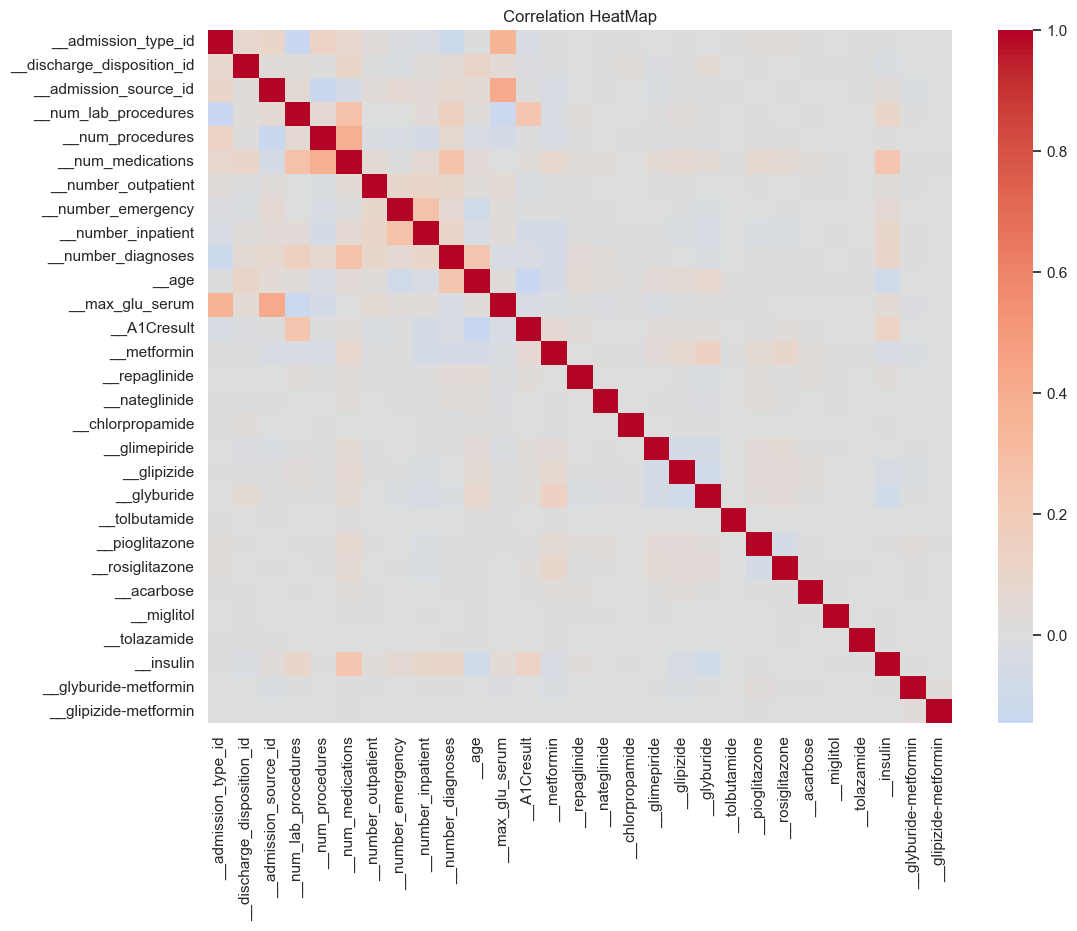

Dropped 0 highly correlated features: []


(81412, 1163)

(20354, 1163)

(81412, 2)

(20354, 2)

In [12]:
#--------------------------------------------------------------------------------------
#9..Identifying and Removing High Correlation Features from X_train with MinMax Scaling
#----------------------------------------------------------------------------------------

corr = X_train_StdScale.loc[:,numeric_ordinal_col].corr()
plt.figure(figsize=(12,9))
sns.heatmap(X_train_StdScale.loc[:,numeric_ordinal_col].corr(),cmap='coolwarm',center=0)
plt.title('Correlation HeatMap')
plt.show()


# To identify and drop the features with correlation >0.75
def drop_high_correlation(df, threshold=0.75):
    corr_map = df.corr(numeric_only=True).abs()
    upper_tri = corr_map.where(np.triu(np.ones(corr_map.shape), k=1).astype(bool) )
    to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]
    df_cleaned = df.drop(columns=to_drop)
    print(f"Dropped {len(to_drop)} highly correlated features: {to_drop}")    
    return to_drop

dropped_cols = drop_high_correlation(X_train_StdScale.loc[:, numeric_ordinal_col])
X_train_StdScale = X_train_StdScale.drop(columns=dropped_cols)
X_test_StdScale = X_test_StdScale.drop(columns=dropped_cols)

display(X_train_StdScale.shape, X_test_StdScale.shape)
display(y_train.shape, y_test.shape)


## Section 1.4: Selection of Final PrePorcessing Approach
Based on the Model iterations
- MInMax Scaling along with PCA has been used for clustering. Since redcuing data variance would well suits clustering.
- Similarly, Standard Scaling and 'No Scaling' approaches have been evaluated for Regression and classification. 

## ******** End Of PreProcessing****************

*****
## Section 2: Clustering (Model Comparison and Selection)

Two distinghuished modelling approaches consdiered for the clustering, since the data overlaps are not clear at this stage due to large number of features (1160+) and the higher number of training data

- Model 1: K-Means++ (Model-1) --> To capture if the data has clear bounded clusters 
- Model 2: Gaussian Mixture Models (GMM) - Model-2 --> To capture if the data as overlap regions

Since there are 1160+ features which could be a curse of dimensaionality and need to go for PCA. PCA extraction would select the top contributing fetaures to capture the vairiance in the data.

The common methods which can compare K-Means++ and GMM:
- Silhoutte Score : Approach based on closeness of clsuter points ranked from -1 to +1
- DBCV: Density based cluster validation meant for clusers of diffeent densities, shapes


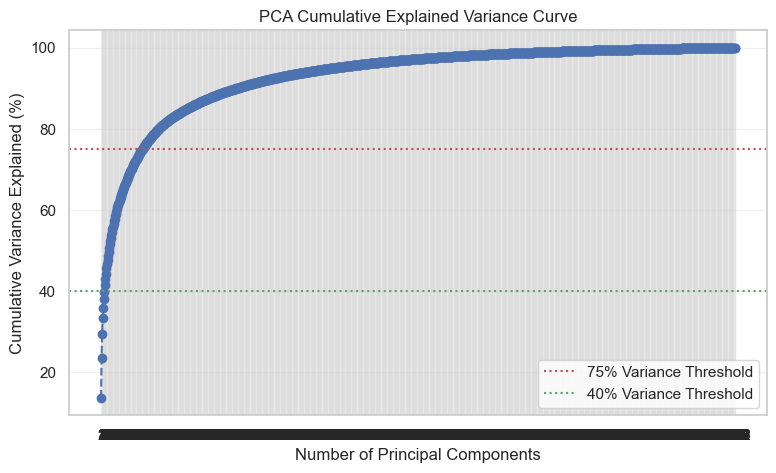

To capture at least 75% of your data's variance, you need: 77 PCs
To capture at least 40% of your data's variance, you need: 8 PCs


In [13]:
#-----------------------------------------------------------
# Feature Engineering for Clustering: PCA
#-----------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Fit PCA with no component limit to look at the entire dataset structure
pca_full = PCA(random_state=42)
pca_full.fit(X_train_MinMax) # Assuming X_train is standard-scaled

# 2. Calculate the cumulative sum of explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_) * 100

# 3. Plot the information curve
plt.figure(figsize=(9, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='b')

# Draw a red target line at 75% variance
plt.axhline(y=75, color='r', linestyle=':', label='75% Variance Threshold')
plt.axhline(y=40, color='g', linestyle=':', label='40% Variance Threshold')

plt.title('PCA Cumulative Explained Variance Curve')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance Explained (%)')
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 4. Programmatically find out exactly how many components you need for 75% variance
min_pcs = np.argmax(cumulative_variance >= 75) + 1
min_pcs_40 = np.argmax(cumulative_variance >= 40) + 1
print(f"To capture at least 75% of your data's variance, you need: {min_pcs} PCs")
print(f"To capture at least 40% of your data's variance, you need: {min_pcs_40} PCs")


PCA: It is observed that out of 1163 features, 77 components are needed to explain 75% of total dataset variance. Whereas 40% variance can be capture by just 8 PCAs

## Section 2.2: FIRST CLUSTERING APPROACH (K-Mean++)
K-Means++ holds a optimum intialization method to center the clusters well. It runs faster and scales easily to 100000 rows. Preferred for datasets having clear spherical boundaries. 

In [14]:
#-----------------------------------------------------------
# K-Means++ Model
#----------------------------------------------------------

import hdbscan
import plotly.express as px 
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE 
from sklearn.metrics import silhouette_score

# --- 1. RUN PCA DIMENSIONALITY REDUCTION ---
# Added PCA initialization and transformation here
pca = PCA(n_components=6, random_state=42)
X_train_pca_km = pca.fit_transform(X_train_MinMax)

# --- 2. SET UP THE EVALUATION RANGE ---
k_values = [2, 3, 4, 5, 6, 7, 8]

inertia_scores = []
mse_scores = []
silhouette_scores = []
dbcv_scores = []

# --- 3. SAMPLE PREPARATION FOR EVALUATION ---
MAX_SAMPLES = 5000

if len(X_train_pca_km) > MAX_SAMPLES:
    rng = np.random.default_rng(42)
    sample_indices_km = rng.choice(
        len(X_train_pca_km), size=MAX_SAMPLES, replace=False
    )
    # Using standard NumPy brackets here because X_train_pca is an array
    X_train_sample_km = X_train_pca_km[sample_indices_km]
else:
    sample_indices_km = None
    X_train_sample_km = X_train_pca_km

# Optimize layout for DBCV
X_train_sample_km_dbcv = np.ascontiguousarray(X_train_sample_km, dtype=np.float64)


# --- 4. RUN K-MEANS++ LOOP ---
for k in k_values:
    # Fit model on the FULL PCA-transformed dataset
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42)
    labels = kmeans.fit_predict(X_train_pca_km)

    inertia = kmeans.inertia_
    inertia_scores.append(inertia)

    # Mean Squared Error (Full Data)
    mse = inertia / len(X_train_pca_km)
    mse_scores.append(mse)

    # Filter labels down to match the evaluation sample
    if sample_indices_km is not None:
        labels_sample_km = labels[sample_indices_km]
    else:
        labels_sample_km = labels

    # Silhouette Score
    sil = silhouette_score(X_train_sample_km, labels_sample_km)
    silhouette_scores.append(sil)

    # DBCV Score
    try:
        dbcv_val = hdbscan.validity.validity_index(
            X_train_sample_km_dbcv, labels_sample_km
        )
        dbcv_scores.append(dbcv_val)
    except Exception:
        dbcv_scores.append(np.nan)


# --- 5. DISPLAY PERFORMANCE SUMMARY REPORT ---
summary_df = pd.DataFrame(
    {
        "Clusters (K)": k_values,
        "Inertia": inertia_scores,
        "MSE (Quantization)": mse_scores,
        "Silhouette Score": silhouette_scores,
        "DBCV Score": dbcv_scores,
    }
).set_index("Clusters (K)")

print("K-Means++ Clustering Evaluation Report (PCA Data, Metrics Sampled on 5000 points):")
display(summary_df.round(4))


K-Means++ Clustering Evaluation Report (PCA Data, Metrics Sampled on 5000 points):


,Inertia,MSE (Quantization),Silhouette Score,DBCV Score
Clusters (K),,,,
2,119427.9707,1.4670,0.2854,0.0039
3,94820.3671,1.1647,0.3094,-0.3315
4,76804.9859,0.9434,0.3566,0.0302
5,57919.1660,0.7114,0.4222,0.2418
6,51875.5865,0.6372,0.4364,-0.2016
7,38088.2397,0.4678,0.5202,0.1513
8,34743.6414,0.4268,0.5296,-0.1136


### K-Means++ Selection of PCAs: 

Number of PCs were manually varied to see the goodness of clustering and, observed that considering 6 PCs would be a optimum number for this method

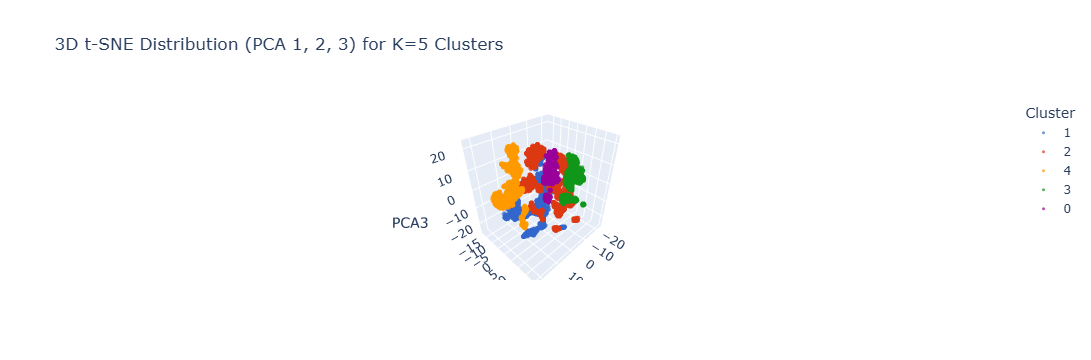

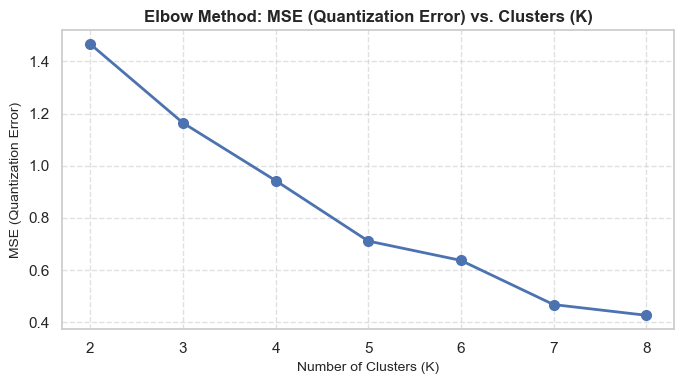

In [15]:
#-----------------------------------------------------------
# K-Means ++ Contd.. Plotting and Visualization of Metrics
#-----------------------------------------------------------

# --- 6. 3D TSNE PLOT SPECIFICALLY FOR K=5 ---

# Generate the cluster labels specifically for K=5 
kmeans_5 = KMeans(n_clusters=5, init="k-means++", random_state=42)
labels_full_5 = kmeans_5.fit_predict(X_train_pca_km)

# Match the labels to our 5,000 downsampled evaluation points
if sample_indices_km is not None:
    labels_sample_km_5 = labels_full_5[sample_indices_km]
else:
    labels_sample_km_5 = labels_full_5

# Isolate the top 3 principal components (PCA 1, 2, 3) from our sampled data
X_sample_pca_123 = X_train_sample_km[:, 0:3]

# Fit 3D t-SNE to translate those components into 3 coordinate axes
tsne_3d = TSNE(n_components=3, perplexity=30, random_state=42, n_jobs=-1)
tsne_embedding = tsne_3d.fit_transform(X_sample_pca_123)

# Build a DataFrame for plot
tsne_df = pd.DataFrame(tsne_embedding, columns=["PCA1", "PCA2", "PCA3"])
tsne_df["Cluster"] = labels_sample_km_5.astype(str)

fig = px.scatter_3d(
    tsne_df,
    x="PCA1",
    y="PCA2",
    z="PCA3",
    color="Cluster",
    title="3D t-SNE Distribution (PCA 1, 2, 3) for K=5 Clusters",
    opacity=0.7,
    color_discrete_sequence=px.colors.qualitative.G10,
)
fig.update_traces(marker=dict(size=3))
fig.show()

# ---7. Elbow Plot for K vs MSE (Quantization)
plt.figure(figsize=(7, 4))
plt.plot(k_values, mse_scores, "bo-", linewidth=2, markersize=7)
plt.title("Elbow Method: MSE (Quantization Error) vs. Clusters (K)", fontsize=12, fontweight="bold")
plt.xlabel("Number of Clusters (K)", fontsize=10)
plt.ylabel("MSE (Quantization Error)", fontsize=10)
plt.xticks(k_values)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### K-Means++ Final Observations: 
MSE Quantization suggests that K=5 and K=7 would be good estiamte to capture the clusters. Same can be observed in t-SNE plot.
Silhoutte score of 0.422 with higher positive DBCV score for K=5 suggests an acceptable clustering


## Section 2.3: SECOND CLUSTERING APPROACH (Gaussian Mixture Model)
GMM follows elliptical gaussian, Extermely suitable for datasets with overlapping clusters and good variation in the data. Well suited for overlapping age groups and mixed medical conditions

In [16]:
#-----------------------------------------------------------
# Gaussian Mixture Model
#-----------------------------------------------------------

import plotly.express as px
from sklearn.mixture import GaussianMixture 

# --- 1. RUN PCA DIMENSIONALITY REDUCTION ---
pca = PCA(n_components=5, random_state=42)
X_train_pca = pca.fit_transform(X_train_MinMax)

# --- 2. SET UP THE EVALUATION RANGE ---
k_values = [2, 3, 4, 5, 6, 7, 8]

nllh_scores = []  # Replaced inertia_scores and mse_scores with NLLH
silhouette_scores = []
dbcv_scores = []

# --- 3. SAMPLE PREPARATION FOR EVALUATION ---
MAX_SAMPLES = 5000

if len(X_train_pca) > MAX_SAMPLES:
    rng = np.random.default_rng(42)
    sample_indices = rng.choice(
        len(X_train_pca), size=MAX_SAMPLES, replace=False
    )
    X_train_sample = X_train_pca[sample_indices]
else:
    sample_indices = None
    X_train_sample = X_train_pca

# Optimize layout for DBCV
X_train_sample_dbcv = np.ascontiguousarray(X_train_sample, dtype=np.float64)


# --- 4. RUN GMM LOOP ---
for k in k_values:
    # Fit GMM on the FULL PCA-transformed dataset
    gmm = GaussianMixture(n_components=k, random_state=42)
    labels = gmm.fit_predict(X_train_pca)

    # 1. Calculate Negative Log-Likelihood (NLLH) on Full Data
    # .score_samples computes log-likelihood per sample; mean over dataset inverted gives NLLH
    log_likelihood = gmm.score_samples(X_train_pca)
    nllh = -np.mean(log_likelihood)
    nllh_scores.append(nllh)

    # Filter labels down to match the evaluation sample
    if sample_indices is not None:
        labels_sample = labels[sample_indices]
    else:
        labels_sample = labels

    # 2. Calculate Silhouette Score (Sampled Data)
    sil = silhouette_score(X_train_sample, labels_sample)
    silhouette_scores.append(sil)

    # 3. Calculate DBCV Score (Sampled Data)
    try:
        dbcv_val = hdbscan.validity.validity_index(
            X_train_sample_dbcv, labels_sample
        )
        dbcv_scores.append(dbcv_val)
    except Exception:
        dbcv_scores.append(np.nan)


# --- 5. DISPLAY PERFORMANCE SUMMARY REPORT ---
summary_df = pd.DataFrame(
    {
        "Clusters (K)": k_values,
        "Negative Log-Likelihood (NLLH)": nllh_scores,  # Updated column map
        "Silhouette Score": silhouette_scores,
        "DBCV Score": dbcv_scores,
    }
).set_index("Clusters (K)")

print("GMM Clustering Evaluation Report (PCA Data, Metrics Sampled on 5000 points):")
display(summary_df.round(4))

GMM Clustering Evaluation Report (PCA Data, Metrics Sampled on 5000 points):


,Negative Log-Likelihood (NLLH),Silhouette Score,DBCV Score
Clusters (K),,,
2,0.5128,0.3614,-0.0934
3,-1.1374,0.3896,-0.0937
4,-2.4319,0.4073,0.0507
5,-3.7252,0.4758,0.3577
6,-4.3307,0.4925,0.0972
7,-4.9537,0.5946,0.2766
8,-5.1132,0.6330,0.0597


##### GMM Selection of PCAs: 
Number of PCs were manullay varied to see the goodness of clustering and it was observed that considering 5 PCs would be a optimum number for this method

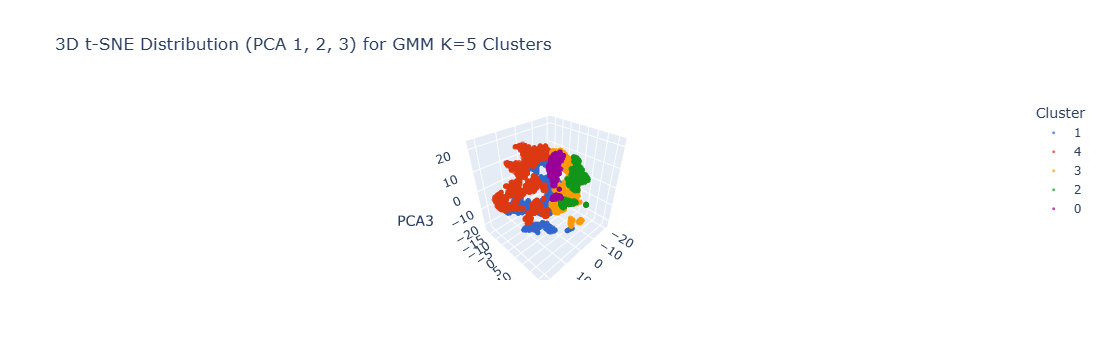

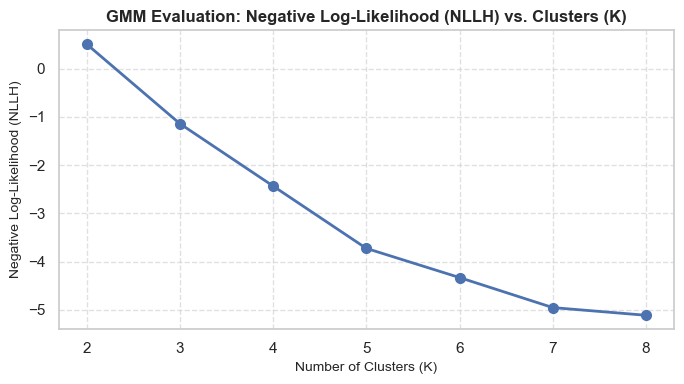

In [17]:
#-----------------------------------------------------------
# GMM Continues... Plotting and Visulaization
#-----------------------------------------------------------

# --- 6. GENERATE 3D TSNE PLOT SPECIFICALLY FOR K=5 WITH GMM ---

gmm_5 = GaussianMixture(n_components=5, random_state=42)
labels_full_5 = gmm_5.fit_predict(X_train_pca)

# Match the labels to 5,000 evaluation points
if sample_indices is not None:
    labels_sample_5 = labels_full_5[sample_indices]
else:
    labels_sample_5 = labels_full_5

# Isolate the top 3 principal components (PCA 1, 2, 3) 
X_sample_pca_123 = X_train_sample[:, 0:3]

# Fit 3D t-SNE to translate those components into 3 coordinate axes
tsne_3d = TSNE(n_components=3, perplexity=30, random_state=42, n_jobs=-1)
tsne_embedding = tsne_3d.fit_transform(X_sample_pca_123)

# Build a DataFrame plot
tsne_df = pd.DataFrame(tsne_embedding, columns=["PCA1", "PCA2", "PCA3"])
tsne_df["Cluster"] = labels_sample_5.astype(str)

fig = px.scatter_3d(
    tsne_df,
    x="PCA1",
    y="PCA2",
    z="PCA3",
    color="Cluster",
    title="3D t-SNE Distribution (PCA 1, 2, 3) for GMM K=5 Clusters",
    opacity=0.7,
    color_discrete_sequence=px.colors.qualitative.G10,
)
fig.update_traces(marker=dict(size=3))
fig.show()

#6. NLL vs K-Plot
plt.figure(figsize=(7, 4))
plt.plot(k_values, nllh_scores, "bo-", linewidth=2, markersize=7)
plt.title("GMM Evaluation: Negative Log-Likelihood (NLLH) vs. Clusters (K)", fontsize=12, fontweight="bold")
plt.xlabel("Number of Clusters (K)", fontsize=10)
plt.ylabel("Negative Log-Likelihood (NLLH)", fontsize=10)
plt.xticks(k_values)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

##### GMM Observations: 
Negative Loglikelihood suggests a good convergance with clusters(K). 
Silhoutte score of 0.475 with positive DBCV score of 0.358 for K=5 suggests a good clustering with acceptable density regions

In [18]:
# --------------------------------------------------
# Predcition of Cluster Labels with Final Model (GMM)
# ---------------------------------------------------

X_test_pca = pca.transform(X_test_MinMax) if 'X_test_MinMax' in locals() else pca.transform(X_test)
train_labels = gmm_5.predict(X_train_pca)
test_labels = gmm_5.predict(X_test_pca)

# -----------------------------
# Combined to patient label column
# -----------------------------
train_patient_label_df = pd.DataFrame({"patient_label": train_labels})
test_patient_label_df = pd.DataFrame({"patient_label": test_labels})

train_patient_label_df.index = X_train.index
test_patient_label_df.index = X_test.index


combined_labels = pd.concat([train_patient_label_df, test_patient_label_df], axis=0)

print("Combined patient_label shape:", combined_labels.shape)
combined_labels.head()

Combined patient_label shape: (101766, 1)


,patient_label
24079,2
98079,0
6237,4
72208,4
33075,2


## Section 2.4: Selection of Final Approach

K-Means++ Clustering: at K=5:
- Silhouette Score: 0.4222, DBCV Score:0.2418

GMM Clustering: at K=5:
- Silhouette Score: 0.4758, DBCV Score:0.3577

Since the data visulaization shows strong overlap of clusters, GMM would be a go to cluster method comapred to K-Mean++. Metrics also suggest that K=5 would be good estimate of cluster parameters interms of capturing the densities and points within the clsuter

In [19]:
#---------------------------------------------------------------------------
# Final Step: Integrating 'Patient segemnt label' prediction from Clustering
#--------------------------------------------------------------------------

X_train = pd.concat([X_train, train_patient_label_df], axis=1)
X_test = pd.concat([X_test, test_patient_label_df], axis=1)
display(X_train.head(5), X_test.head(5))


,mixed_cat__diag_1_112,mixed_cat__diag_1_135,mixed_cat__diag_1_150,mixed_cat__diag_1_151,mixed_cat__diag_1_152,mixed_cat__diag_1_153,mixed_cat__diag_1_154,mixed_cat__diag_1_155,mixed_cat__diag_1_156,mixed_cat__diag_1_157,mixed_cat__diag_1_158,mixed_cat__diag_1_161,mixed_cat__diag_1_162,mixed_cat__diag_1_171,mixed_cat__diag_1_174,mixed_cat__diag_1_182,mixed_cat__diag_1_183,mixed_cat__diag_1_185,mixed_cat__diag_1_188,mixed_cat__diag_1_189,mixed_cat__diag_1_191,mixed_cat__diag_1_193,mixed_cat__diag_1_196,mixed_cat__diag_1_197,mixed_cat__diag_1_198,mixed_cat__diag_1_199,mixed_cat__diag_1_200,mixed_cat__diag_1_202,mixed_cat__diag_1_203,mixed_cat__diag_1_204,mixed_cat__diag_1_205,mixed_cat__diag_1_211,mixed_cat__diag_1_218,mixed_cat__diag_1_220,mixed_cat__diag_1_225,mixed_cat__diag_1_226,mixed_cat__diag_1_227,mixed_cat__diag_1_233,mixed_cat__diag_1_235,mixed_cat__diag_1_238,...,standard_cat__race_Asian,standard_cat__race_Caucasian,standard_cat__race_Hispanic,standard_cat__race_Other,standard_cat__gender_Female,standard_cat__gender_Male,standard_cat__change_Ch,standard_cat__change_No,standard_cat__diabetesMed_No,standard_cat__diabetesMed_Yes,__admission_type_id,__discharge_disposition_id,__admission_source_id,__num_lab_procedures,__num_procedures,__num_medications,__number_outpatient,__number_emergency,__number_inpatient,__number_diagnoses,__age,__max_glu_serum,__A1Cresult,__metformin,__repaglinide,__nateglinide,__chlorpropamide,__glimepiride,__glipizide,__glyburide,__tolbutamide,__pioglitazone,__rosiglitazone,__acarbose,__miglitol,__tolazamide,__insulin,__glyburide-metformin,__glipizide-metformin,patient_label
24079,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,7.0,48.0,0.0,11.0,0.0,0.0,0.0,9.0,7.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
98079,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,7.0,42.0,0.0,5.0,0.0,0.0,0.0,6.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
6237,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,7.0,44.0,0.0,10.0,0.0,0.0,0.0,7.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
72208,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,3.0,7.0,54.0,0.0,8.0,0.0,0.0,0.0,8.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4
33075,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,11.0,7.0,35.0,3.0,23.0,0.0,0.0,1.0,8.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2


,mixed_cat__diag_1_112,mixed_cat__diag_1_135,mixed_cat__diag_1_150,mixed_cat__diag_1_151,mixed_cat__diag_1_152,mixed_cat__diag_1_153,mixed_cat__diag_1_154,mixed_cat__diag_1_155,mixed_cat__diag_1_156,mixed_cat__diag_1_157,mixed_cat__diag_1_158,mixed_cat__diag_1_161,mixed_cat__diag_1_162,mixed_cat__diag_1_171,mixed_cat__diag_1_174,mixed_cat__diag_1_182,mixed_cat__diag_1_183,mixed_cat__diag_1_185,mixed_cat__diag_1_188,mixed_cat__diag_1_189,mixed_cat__diag_1_191,mixed_cat__diag_1_193,mixed_cat__diag_1_196,mixed_cat__diag_1_197,mixed_cat__diag_1_198,mixed_cat__diag_1_199,mixed_cat__diag_1_200,mixed_cat__diag_1_202,mixed_cat__diag_1_203,mixed_cat__diag_1_204,mixed_cat__diag_1_205,mixed_cat__diag_1_211,mixed_cat__diag_1_218,mixed_cat__diag_1_220,mixed_cat__diag_1_225,mixed_cat__diag_1_226,mixed_cat__diag_1_227,mixed_cat__diag_1_233,mixed_cat__diag_1_235,mixed_cat__diag_1_238,...,standard_cat__race_Asian,standard_cat__race_Caucasian,standard_cat__race_Hispanic,standard_cat__race_Other,standard_cat__gender_Female,standard_cat__gender_Male,standard_cat__change_Ch,standard_cat__change_No,standard_cat__diabetesMed_No,standard_cat__diabetesMed_Yes,__admission_type_id,__discharge_disposition_id,__admission_source_id,__num_lab_procedures,__num_procedures,__num_medications,__number_outpatient,__number_emergency,__number_inpatient,__number_diagnoses,__age,__max_glu_serum,__A1Cresult,__metformin,__repaglinide,__nateglinide,__chlorpropamide,__glimepiride,__glipizide,__glyburide,__tolbutamide,__pioglitazone,__rosiglitazone,__acarbose,__miglitol,__tolazamide,__insulin,__glyburide-metformin,__glipizide-metformin,patient_label
35956,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,6.0,68.0,0.0,20.0,0.0,0.0,0.0,5.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3
60927,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,20.0,0.0,7.0,0.0,0.0,0.0,8.0,5.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
79920,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,3.0,6.0,1.0,21.0,3.0,23.0,1.0,0.0,2.0,7.0,6.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
50078,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,2.0,1.0,1.0,28.0,0.0,19.0,0.0,0.0,1.0,7.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
44080,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,2.0,7.0,21.0,0.0,6.0,0.0,0.0,0.0,7.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3


*****
## Section 3: Regression
### Model Choices
LightGBM Regression with K-folds (Model-1) and Random Forest Regression with K-folds (Model-2) 

### Data Set Consideration
- Considered final preprocessed data without scaling for the selected models. Tried one iteration with standardscaling but the fit was not  satisifactory
- Since the tree‑based regression models (LightGBM and Random forest) split data based on raw feature values and doesn't require scaling.
- Patient segment label from clustering has been included
- K-fold CV method is considered to predict the length of stays across the trainign set and holdout test set
  
### Common Metrics Chosen for Comparison
- RSS (Residual Sum of Square): Shows how well the predcited target is close to training target thorugout observations
- MAE(Mean Average Error): Gives average mean deviation of whole data set
- R2: How well the variance is captured compared to exisitng variance in y.

### Plots:
- Scatter Plot of y features
- Histogram plot showing the Residual (Actual - Predicted)


## Section 3.1: FIRST REGRESSION APPROACH

### Model Choice-1: LightGBM Regressor
- Recommended for datasets with many categorical and mixed-type features
- Works well when predicting integer/discrete numeric targets (like length of stay)
- Each boosting iteration uses all features and chooses splits that give the largest reduction in loss
- Suitable for high-variance, non-linear datasets
- Fast training and good performance on large datasets


In [20]:
#---------------------------------------------------------------------
# LightGBM Regressor : Model Training and Out-of-Fold (OOF) Generation
#--------------------------------------------------------------------

import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error


# 1. Define hyperparameters

params = {
    'objective': 'poisson',       
    'metric': 'poisson',
    'learning_rate': 0.03,        
    'num_leaves': 63,             
    'max_depth': 8,               
    'feature_fraction': 0.7,      
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'n_jobs': -1
}

# 2. Setup K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 3. Use only 'time_in_hospital' from y_train
y_train_lgbr = y_train['time_in_hospital'].values

# 4. Array to hold out-of-fold predictions for the training data
oof_predictions = np.zeros(X_train.shape[0])


# 5. List to store trained models for prediction
trained_lgbr_models = []

print("Starting K-Fold Cross-Validation & OOF Generation...")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_train, y_train_lgbr), 1):
    X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_va = y_train_lgbr[train_idx], y_train_lgbr[val_idx]
    cats = ['__admission_type_id', '__discharge_disposition_id', '__admission_source_id']   
    train_data = lgb.Dataset(X_tr, label=y_tr, categorical_feature=cats)
    val_data = lgb.Dataset(X_va, label=y_va, reference=train_data, categorical_feature=cats)
    
    # Train model with Early Stopping
    lgbr_model = lgb.train(
        params,
        train_data,
        num_boost_round=1000,
        valid_sets=[val_data],
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
    )
    
    trained_lgbr_models.append(lgbr_model)
    oof_predictions[val_idx] = lgbr_model.predict(X_va, num_iteration=lgbr_model.best_iteration)

# 6. Evaluate the Out-of-Fold performance matrix
r2 = r2_score(y_train_lgbr, oof_predictions)
mae = mean_absolute_error(y_train_lgbr, oof_predictions)
rss = np.sum((y_train_lgbr - oof_predictions) ** 2)

print("\n=== Out-of-Fold Evaluation Matrix ===")
print(f"OOF R2 Score : {r2:.4f}")
print(f"OOF RSS      : {rss:.4f}")
print(f"OOF MAE      : {mae:.4f}")

# 7. Create the required feature for your development/training classification task
# If X_train_StdScale is a numpy array, convert OOF to a DataFrame feature
X_train_with_oof_lgbr = pd.DataFrame(X_train) 
X_train_with_oof_lgbr['predicted_length_of_stay'] = oof_predictions
print("\nSuccessfully generated 'predicted_length_of_stay' for training data.")

Starting K-Fold Cross-Validation & OOF Generation...

=== Out-of-Fold Evaluation Matrix ===
OOF R2 Score : 0.4766
OOF RSS      : 381914.1804
OOF MAE      : 1.6080

Successfully generated 'predicted_length_of_stay' for training data.


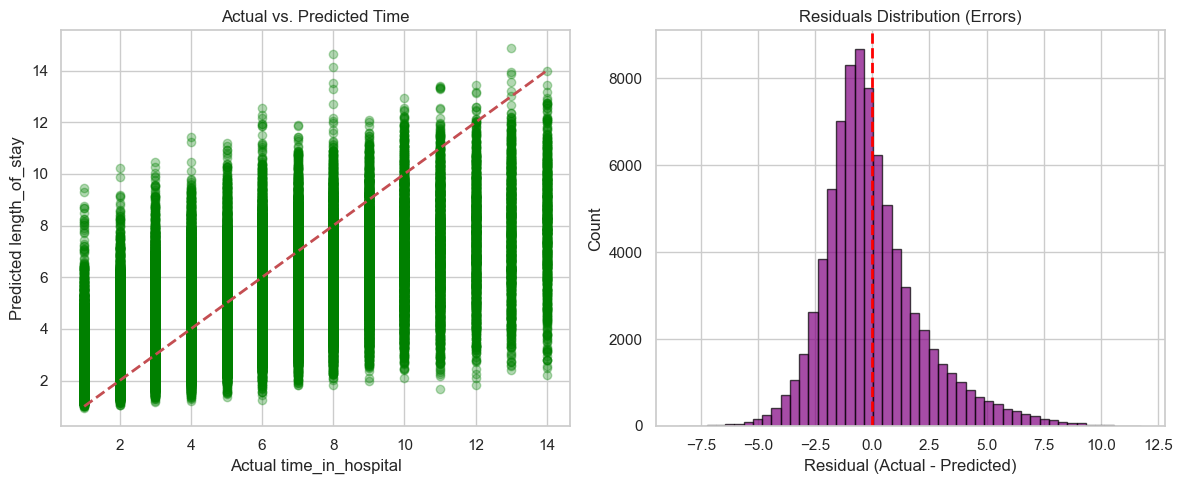

In [21]:
#------------------------------------------------------------------------------
# LightGBM Regressor Contd... : Model Training and Out-of-Fold (OOF) Generation
#--------------------------------------------------------------------------------

import matplotlib.pyplot as plt

# 8. Visual Evaluation Plots
plt.figure(figsize=(12, 5))

# Plot 1: Compare Actual vs Predicted Time
plt.subplot(1, 2, 1)
plt.scatter(y_train_lgbr, oof_predictions, alpha=0.3, color='green')
plt.plot([y_train_lgbr.min(), y_train_lgbr.max()], [y_train_lgbr.min(), y_train_lgbr.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted Time')
plt.xlabel('Actual time_in_hospital')
plt.ylabel('Predicted length_of_stay')
plt.grid(True)

LGBresiduals = y_train_lgbr - oof_predictions

# 9: Residuals Distribution
plt.subplot(1, 2, 2)
plt.hist(LGBresiduals, bins=50, color='purple', alpha=0.7, edgecolor='black')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title('Residuals Distribution (Errors)')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Count')
plt.grid(True)

plt.tight_layout()
plt.show()

## Section 3.3: SECOND REGRESSION APPROACH

### Model Choice-2: Random Forest Regressor
- A strong model for datasets with high categorical and mixed-type features
- Good for predicting integer or discrete numeric targets
- Each tree is trained on a random subset of features, which reduces overfitting and improves robustness
- Works well for non-linear datasets and performs reliably on medium-sized datasets
- Training can be computationally expensive when dataset becomes large

In [22]:
#------------------------------------------------------------------------
# Model Training and Out-of-Fold (OOF) Generation (Random Forest Version)
#------------------------------------------------------------------------
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# --- ASSUMPTIONS ---
# X_train: Your feature matrix (ensure cats columns are already numeric/encoded)
# y_train: Your training target series/array (time_in_hospital)
# -------------------

# 1. Define hyperparameters for Random Forest
# Max features is dropped to 0.3 (~30%) to handle the 1,160+ columns efficiently
rf_params = {
    'n_estimators': 300,          
    'max_depth': 12,              
    'max_features': 0.3,          
    'min_samples_leaf': 4,        
    'n_jobs': -1,                 
    'random_state': 42
}

# 2. Setup K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Training target: 'time_in_hospital' from y_train
y_train_rf = y_train['time_in_hospital'].values

# Array to hold out-of-fold predictions for the training data
oof_predictions_rf = np.zeros(X_train.shape[0])

# List to store trained models for later test-set prediction
trained_rf_models = []

print("Starting K-Fold Cross-Validation & OOF Generation (Random Forest)...")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_train, y_train_rf), 1):
    # Slice the training and internal validation folds
    # Note: Ensure the categorical columns ('cats') in X_train are numeric integers before this step
    X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_va = y_train_rf[train_idx], y_train_rf[val_idx]
    
    # Initialize the Random Forest model with your specified parameters
    rf_model = RandomForestRegressor(**rf_params)
    
    # Train model (Random Forest doesn't use early stopping callbacks like LightGBM)
    rf_model.fit(X_tr, y_tr)
    
    # Save the trained fold model
    trained_rf_models.append(rf_model)
    
    # Generate true out-of-fold predictions for this validation block
    oof_predictions_rf[val_idx] = rf_model.predict(X_va)
    print(f"Fold {fold} complete.")

# 3. Evaluate the Out-of-Fold performance matrix
r2 = r2_score(y_train_rf, oof_predictions_rf)
mae = mean_absolute_error(y_train_rf, oof_predictions_rf)
rss = np.sum((y_train_rf - oof_predictions_rf) ** 2)

print("\n=== Out-of-Fold Evaluation Matrix (Random Forest) ===")
print(f"OOF R2 Score : {r2:.4f}")
print(f"OOF RSS      : {rss:.4f}")
print(f"OOF MAE      : {mae:.4f}")

# 4. Create the required feature for your development/training classification task
X_train_with_oof_rf = pd.DataFrame(X_train) 
X_train_with_oof_rf['predicted_length_of_stay'] = oof_predictions_rf

print("\nSuccessfully generated 'predicted_length_of_stay' for training data using Random Forest.")

Starting K-Fold Cross-Validation & OOF Generation (Random Forest)...
Fold 1 complete.
Fold 2 complete.
Fold 3 complete.
Fold 4 complete.
Fold 5 complete.

=== Out-of-Fold Evaluation Matrix (Random Forest) ===
OOF R2 Score : 0.4185
OOF RSS      : 424315.3142
OOF MAE      : 1.7156

Successfully generated 'predicted_length_of_stay' for training data using Random Forest.


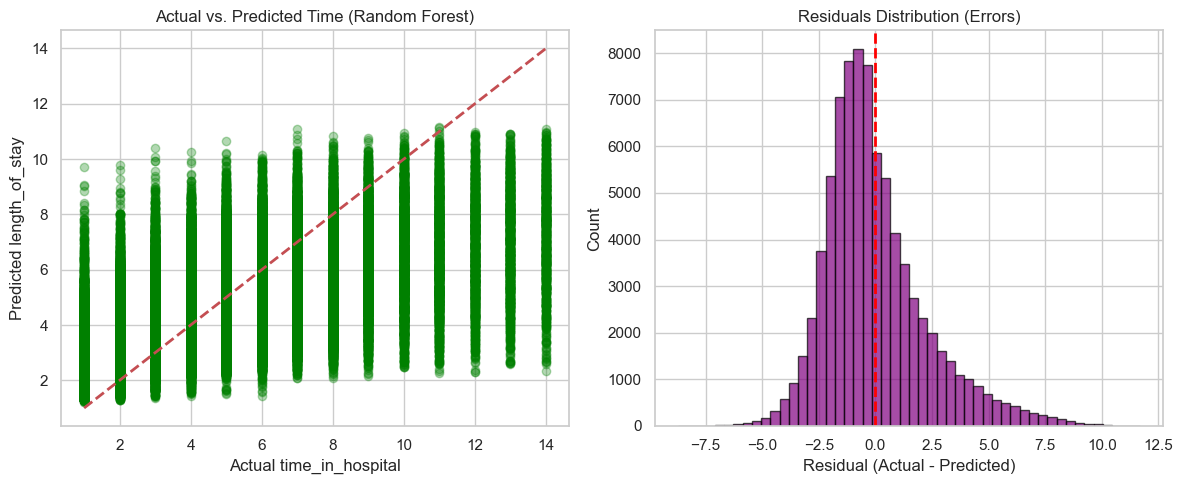

In [23]:
# -------------------------------------------------------------------------
# 5. Random Forest Regressor contd..: Visual Evaluation Plots
# -------------------------------------------------------------------------
# Calculate residuals
RF_residuals = y_train_rf - oof_predictions_rf

plt.figure(figsize=(12, 5))

# Plot 1: Actual vs. Predicted Scatter
plt.subplot(1, 2, 1)
plt.scatter(y_train_rf, oof_predictions_rf, alpha=0.3, color='green')
plt.plot([y_train_rf.min(), y_train_rf.max()], 
         [y_train_rf.min(), y_train_rf.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted Time (Random Forest)')
plt.xlabel('Actual time_in_hospital')
plt.ylabel('Predicted length_of_stay')
plt.grid(True)

# Plot 2: Residuals Distribution
plt.subplot(1, 2, 2)
plt.hist(RF_residuals, bins=50, color='purple', alpha=0.7, edgecolor='black')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title('Residuals Distribution (Errors)')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Count')
plt.grid(True)

plt.tight_layout()
plt.show()

## Section 3.4: Selection of Final Approach

Evaluation Metrics from out of fold predcitions for regression for 'predicted_length_of_stay':

Model 1 (LightGBM Regressor)
=== Out-of-Fold Evaluation Matrix ===
- R2 Score : 0.4766
- RSS      : 381914.18
- MAE      : 1.6080

Model 2 (Random Forest Regressor):
=== Out-of-Fold Evaluation Matrix  ===
- R2 Score : 0.4185
- RSS      : 424315.3142
- MAE      : 1.7156

Final Model Selection
- Both models performed well across all the metrics, with a minimal difference in their scores
- computatiopnal time for Random Forest Regressor is observed to be ~5x higher than LightGBM. The highe time for random forest regressor might be due to the inhernet partial feature selection at each tree and demand of large number of tree before convergance
- Purely based on speed, memeory usage and inherent scalability and ease of tuning --> lightGBM regressor has been selected as the final model

In [24]:
#---------------------------------------------------------------------------
# 1. Prediction of 'Length of Stay' using X_test on the Final LightGBM Model
#---------------------------------------------------------------------------

import numpy as np
# 1. Initialize and compute the average predictions across all folds
test_predictions_lgbr = np.zeros(len(X_test))

for lgbr_model in trained_lgbr_models:
    test_predictions_lgbr += lgbr_model.predict(X_test, num_iteration=lgbr_model.best_iteration) / len(trained_lgbr_models)

# 2. Integrate the 'predicted length of stay estimation' into Train DataFrame
train_df = X_train.copy()
# Explicitly matching the index ensures pandas aligns the rows perfectly
train_df['predicted_length_of_stay'] = pd.Series(oof_predictions, index=X_train.index)

# 3. Integrate into Test DataFrame (using averaged 5-fold predictions)
test_df = X_test.copy()
test_df['predicted_length_of_stay'] = test_predictions_lgbr

# 4. Display the first few rows of the modified test set
display(test_df.head())



,mixed_cat__diag_1_112,mixed_cat__diag_1_135,mixed_cat__diag_1_150,mixed_cat__diag_1_151,mixed_cat__diag_1_152,mixed_cat__diag_1_153,mixed_cat__diag_1_154,mixed_cat__diag_1_155,mixed_cat__diag_1_156,mixed_cat__diag_1_157,mixed_cat__diag_1_158,mixed_cat__diag_1_161,mixed_cat__diag_1_162,mixed_cat__diag_1_171,mixed_cat__diag_1_174,mixed_cat__diag_1_182,mixed_cat__diag_1_183,mixed_cat__diag_1_185,mixed_cat__diag_1_188,mixed_cat__diag_1_189,mixed_cat__diag_1_191,mixed_cat__diag_1_193,mixed_cat__diag_1_196,mixed_cat__diag_1_197,mixed_cat__diag_1_198,mixed_cat__diag_1_199,mixed_cat__diag_1_200,mixed_cat__diag_1_202,mixed_cat__diag_1_203,mixed_cat__diag_1_204,mixed_cat__diag_1_205,mixed_cat__diag_1_211,mixed_cat__diag_1_218,mixed_cat__diag_1_220,mixed_cat__diag_1_225,mixed_cat__diag_1_226,mixed_cat__diag_1_227,mixed_cat__diag_1_233,mixed_cat__diag_1_235,mixed_cat__diag_1_238,...,standard_cat__race_Caucasian,standard_cat__race_Hispanic,standard_cat__race_Other,standard_cat__gender_Female,standard_cat__gender_Male,standard_cat__change_Ch,standard_cat__change_No,standard_cat__diabetesMed_No,standard_cat__diabetesMed_Yes,__admission_type_id,__discharge_disposition_id,__admission_source_id,__num_lab_procedures,__num_procedures,__num_medications,__number_outpatient,__number_emergency,__number_inpatient,__number_diagnoses,__age,__max_glu_serum,__A1Cresult,__metformin,__repaglinide,__nateglinide,__chlorpropamide,__glimepiride,__glipizide,__glyburide,__tolbutamide,__pioglitazone,__rosiglitazone,__acarbose,__miglitol,__tolazamide,__insulin,__glyburide-metformin,__glipizide-metformin,patient_label,predicted_length_of_stay
35956,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,6.0,68.0,0.0,20.0,0.0,0.0,0.0,5.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3,5.638728
60927,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,20.0,0.0,7.0,0.0,0.0,0.0,8.0,5.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,2.075411
79920,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,3.0,6.0,1.0,21.0,3.0,23.0,1.0,0.0,2.0,7.0,6.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,3.697384
50078,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,2.0,1.0,1.0,28.0,0.0,19.0,0.0,0.0,1.0,7.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,4.857835
44080,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,2.0,7.0,21.0,0.0,6.0,0.0,0.0,0.0,7.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,2.077365


*****
# Section 4: Classification

### Model Choices:
LightGBM Classifier (Model-1) and XGBoost Classifier (Model-2)

### Data Set Consideration: 
- Considered final preprocessed data without scaling for the selected models. Since the tree‑based models (LightGBM and XGBoost) split data based on raw features and do not require normalization.
- Patient segment label from clustering and predicted length of stay from regression have been included 
- Stratified K-fold CV based on 'patient_nbr' been considered to make sure that all records belonging to that patient remain in the same data partition

### Common Metrics Chosen for Comparison
- ROC-AUC: Shows how well the model separates between 'readmiited in <30, Not' --> Higher the better
- PR-AUC: Measures how well the model identifies true readmissions without false alarms --> Higher the better
- Recall: Penalty for missing a high-risk patient is high, so recall is prioritized over raw precision (Not used here, since F1-score covers)
- Balanced Accuracy / F1-Score: Balances precision and recall -->Higher the better

### Plots:
- Confusion matrix: model decisions for True/False Positives/Negatives
- Shap Summary Plot: Influence of features

# Section 4.1: Common code for classification 

In [25]:
#-----------------------------------------------------------
# Calssification DataSet Preparation
#-----------------------------------------------------------
# integrating the 'predicted length of stay estimation' from regression

X_train = train_df
X_test = test_df

# Creating feature matrix X
X = X_train.drop(columns=['readmitted', 'patient_nbr', 'time_in_hospital'], errors='ignore').copy()
X_test = X_test.drop(columns=['readmitted', 'patient_nbr'], errors='ignore').copy()

# group elements to use for startified K-fold CV
groups = np.asarray(groups).ravel()


## Section 4.2: FIRST CLASSIFICATION APPROACH: LightGBM Classifier
Light GBM models are best in handling high dimensional data with many categorical features. Provides better performance on imbalanced datasets interms of admiited vs not admitted

In [26]:
#-----------------------------------------------------------
#LightGBM Classifier Model Defintion
#-----------------------------------------------------------

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import precision_recall_curve, roc_auc_score, average_precision_score, f1_score, classification_report

# 1. Startified K-fold CV split parameters
n_splits = 5
sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)

y_positive_lgbc = (y_train['readmitted'].isin(['<30']) if isinstance(y_train, pd.DataFrame) else y_train.isin(['<30'])).astype(int).values.ravel()

oof_proba_lgbc = np.zeros(len(X))
lgbc_models = []

print(f"Running {n_splits}-Fold CV on {len(X)} samples...\n")

# 2. Model defintion with K-folds CV
for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y_positive_lgbc, groups=groups), 1):
    X_train_fold_lgbc, y_train_fold_lgbc = X.iloc[train_idx], y_positive_lgbc[train_idx]
    X_val_fold_lgbc, y_val_fold_lgbc = X.iloc[val_idx], y_positive_lgbc[val_idx]
    
    scale_pos_weight = (y_train_fold_lgbc == 0).sum() / (y_train_fold_lgbc == 1).sum()
    
    lgbc_model = lgb.LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='binary_logloss',
        random_state=42,
        n_jobs=-1
    )
    
    lgbc_model.fit(
        X_train_fold_lgbc, y_train_fold_lgbc,
        eval_set=[(X_val_fold_lgbc, y_val_fold_lgbc)],
        callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]
    )
    
    oof_proba_lgbc[val_idx] = lgbc_model.predict_proba(X_val_fold_lgbc)[:, 1]
    lgbc_models.append(lgbc_model)
    
    fold_auc = roc_auc_score(y_val_fold_lgbc, oof_proba_lgbc[val_idx])
    print(f"Fold {fold} | Val ROC-AUC: {fold_auc:.4f}")

# 3. Out-Of-Fold Predictions & Optimal Threshold Calculation

precisions, recalls, thresholds = precision_recall_curve(y_positive_lgbc, oof_proba_lgbc)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_threshold = thresholds[np.argmax(f1_scores)]
oof_pred = (oof_proba_lgbc >= best_threshold).astype(int)

print(f"Best Threshold = {best_threshold:.4f}")


Running 5-Fold CV on 81412 samples...

Fold 1 | Val ROC-AUC: 0.6234
Fold 2 | Val ROC-AUC: 0.6640
Fold 3 | Val ROC-AUC: 0.6442
Fold 4 | Val ROC-AUC: 0.6405
Fold 5 | Val ROC-AUC: 0.6456
Best Threshold = 0.1341


LightGBM Classifier - Performance Metrics based on OOF predcitions
---------------------------------------------
ROC-AUC Score           : 0.6440
PR-AUC Score            : 0.1925
F1-Score (Positive Class): 0.2593
---------------------------------------------

Out-of-Fold Classification Report based on Training Data:

                    precision    recall  f1-score   support

Not Readmitted (0)       0.92      0.70      0.80     72340
    Readmitted (1)       0.17      0.50      0.26      9072

          accuracy                           0.68     81412
         macro avg       0.55      0.60      0.53     81412
      weighted avg       0.84      0.68      0.74     81412

---------------------------------------------


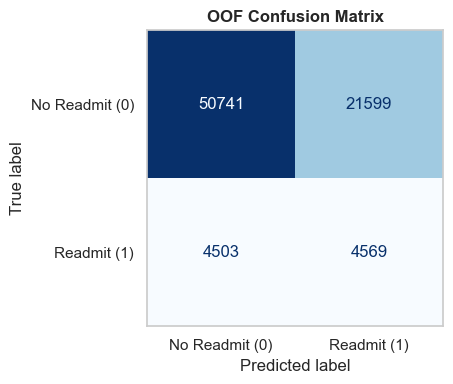

 SHAP Summary Plot on Validation Set...


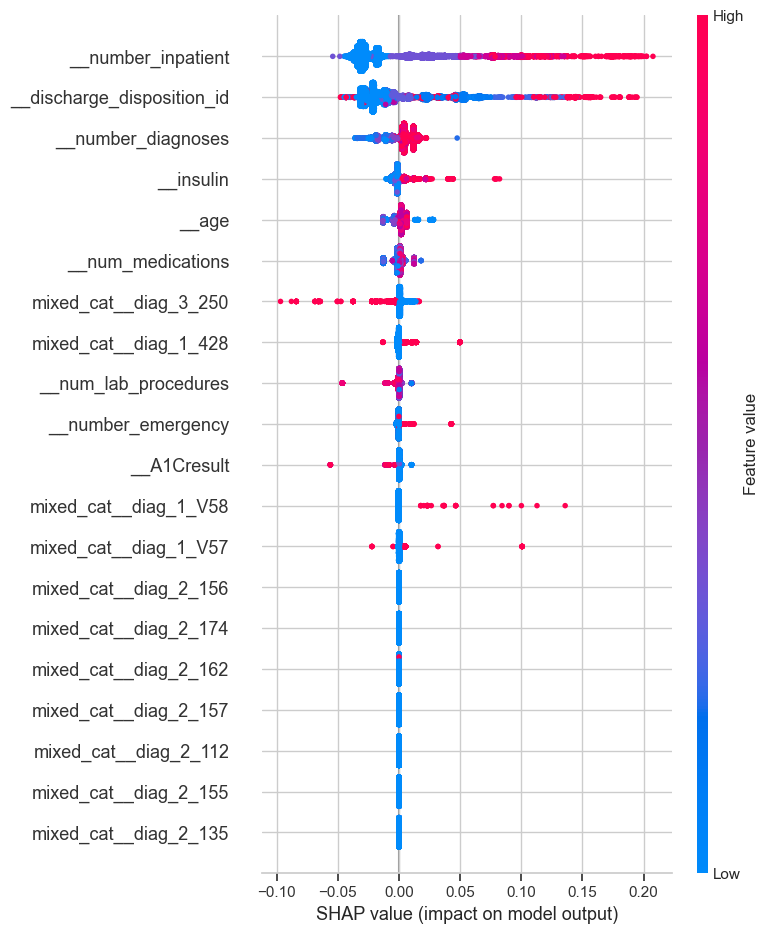

In [27]:
#-----------------------------------------------------------
# Out-Of-Fold Metrics & Classification Report
#-----------------------------------------------------------
from sklearn.metrics import ConfusionMatrixDisplay
import shap

print ("LightGBM Classifier - Performance Metrics based on OOF predcitions") 
print("---------------------------------------------")
cv_roc_auc = roc_auc_score(y_positive_lgbc, oof_proba_lgbc)
cv_pr_auc = average_precision_score(y_positive_lgbc, oof_proba_lgbc)
cv_f1 = f1_score(y_positive_lgbc, oof_pred, pos_label=1)

print(f"ROC-AUC Score           : {cv_roc_auc:.4f}")
print(f"PR-AUC Score            : {cv_pr_auc:.4f}")
print(f"F1-Score (Positive Class): {cv_f1:.4f}")
print("---------------------------------------------")
print("\nOut-of-Fold Classification Report based on Training Data:\n")
print(classification_report(y_positive_lgbc, oof_pred, target_names=['Not Readmitted (0)', 'Readmitted (1)']))
print("---------------------------------------------")

# 4. Confusion Matrix Plot (OOF)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions( y_positive_lgbc, oof_pred, ax=ax, cmap='Blues', colorbar=False, 
                                         display_labels=['No Readmit (0)', 'Readmit (1)'])
ax.set_title('OOF Confusion Matrix', fontsize=12, fontweight='bold')
ax.grid(False)
plt.tight_layout()
plt.show()

# 5. SHAP  Plot for Final Fold
print(" SHAP Summary Plot on Validation Set...")
X_shap = X_val_fold_lgbc
explainer = shap.TreeExplainer(lgbc_models[-1])
shap_values = explainer(X_shap)

plt.figure(figsize=(6, 4))
shap.summary_plot(shap_values, X_shap, plot_type="dot",show=True )

------------------------------------------------------
        TEST SET EVALUATION METRICS (Threshold = 0.1341)
------------------------------------------------------
ROC-AUC Score           : 0.6532
PR-AUC Score            : 0.2018
F1-Score (Positive Class): 0.2651
-------------------------------------------------------

Test Set Classification Report:

                    precision    recall  f1-score   support

Not Readmitted (0)       0.92      0.66      0.77     18069
    Readmitted (1)       0.17      0.56      0.27      2285

          accuracy                           0.65     20354
         macro avg       0.55      0.61      0.52     20354
      weighted avg       0.84      0.65      0.71     20354

------------------------------------------------------


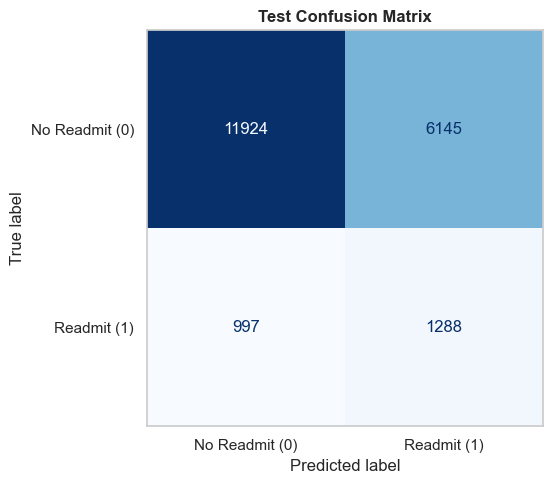

In [28]:
# -------------------------------------------------------------------------
# LightGBM Classifier Contd... : Predcition based on Test Data Set
# -------------------------------------------------------------------------

# 6. Create binary target for test set 
y_test_positive_lgbc = y_test['readmitted'].isin(['<30']).astype(int)
lgbc_model = lgbc_models[-1]  

# 7. Test Predictions Using Trained Model & Saved Threshold
y_test_proba_lgbc = lgbc_model.predict_proba(X_test)[:, 1]
y_test_pred_lgbc = (y_test_proba_lgbc >= best_threshold).astype(int)

# 8. Test Metrics & Classification Report
test_roc_auc = roc_auc_score(y_test_positive_lgbc, y_test_proba_lgbc)
test_pr_auc = average_precision_score(y_test_positive_lgbc, y_test_proba_lgbc)
test_f1 = f1_score(y_test_positive_lgbc, y_test_pred_lgbc, pos_label=1)

print("------------------------------------------------------")
print(f"        TEST SET EVALUATION METRICS (Threshold = {best_threshold:.4f})")
print("------------------------------------------------------")
print(f"ROC-AUC Score           : {test_roc_auc:.4f}")
print(f"PR-AUC Score            : {test_pr_auc:.4f}")
print(f"F1-Score (Positive Class): {test_f1:.4f}")
print("-" * 55)
print("\nTest Set Classification Report:\n")
print(classification_report(y_test_positive_lgbc, y_test_pred_lgbc, target_names=['Not Readmitted (0)', 'Readmitted (1)']))
print("------------------------------------------------------")

# 9. Test Confusion Matrix Plot ONLY
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_positive_lgbc, 
    y_test_pred_lgbc, 
    ax=ax, 
    cmap='Blues', 
    colorbar=False,
    display_labels=['No Readmit (0)', 'Readmit (1)'])
ax.set_title('Test Confusion Matrix', fontsize=12, fontweight='bold')
ax.grid(False)
plt.tight_layout()
plt.show()

## Section 4.3: SECOND CLASSSIFICATION APPROACH: XGBoost Classifier
XGBoost classifier is more stable on noisy medical data and have a mature regularization. Equipped with built in loss-weighting parameters which prevents model from overfitting. Could be slower on large datasets, needs to check.

In [29]:
#-----------------------------------------------------------
# XG Boost Classifier Model Defintion, K-fold CV Prediction
#-----------------------------------------------------------

import xgboost as xgb

# 1. Stratified Group K-Fold Cross-Validation Setup (XGBoost)
n_splits = 5
sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)

y_positive_xg = (y_train['readmitted'].isin(['<30']) if isinstance(y_train, pd.DataFrame) else y_train.isin(['<30'])).astype(int).values.ravel()
y_test_positive_xg = y_test['readmitted'].isin(['<30']).astype(int)

# oof_proba MUST match len(X) exactly
oof_proba_xg = np.zeros(len(X))
xg_models = []

print(f"Running {n_splits}-Fold CV with XGBoost on {len(X)} samples...\n")

for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y_positive_xg, groups=groups), 1):
    X_train_fold_xg, y_train_fold_xg = X.iloc[train_idx], y_positive_xg[train_idx]
    X_val_fold_xg, y_val_fold_xg = X.iloc[val_idx], y_positive_xg[val_idx]
    
    scale_pos_weight = (y_train_fold_xg == 0).sum() / (y_train_fold_xg == 1).sum()
    
    xg_model = xgb.XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        early_stopping_rounds=20,
        enable_categorical=True,  # Crucial for handling pandas category dtypes
        random_state=42,
        n_jobs=-1
    )
    
    xg_model.fit(
        X_train_fold_xg, y_train_fold_xg,
        eval_set=[(X_val_fold_xg, y_val_fold_xg)],
        verbose=False
    )
    
    oof_proba_xg[val_idx] = xg_model.predict_proba(X_val_fold_xg)[:, 1]
    xg_models.append(xg_model)
    
    fold_auc = roc_auc_score(y_val_fold_xg, oof_proba_xg[val_idx])
    print(f"Fold {fold} | Val ROC-AUC: {fold_auc:.4f}")

# 2. Out-Of-Fold Predictions & Optimal Threshold Calculation
precisions, recalls, thresholds = precision_recall_curve(y_positive_xg, oof_proba_xg)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_threshold = thresholds[np.argmax(f1_scores)]

oof_pred_xg = (oof_proba_xg >= best_threshold).astype(int)

print(f"OOF CV EVALUATION METRICS: Optimal Threshold = {best_threshold:.4f})")

Running 5-Fold CV with XGBoost on 81412 samples...

Fold 1 | Val ROC-AUC: 0.6755
Fold 2 | Val ROC-AUC: 0.6768
Fold 3 | Val ROC-AUC: 0.6693
Fold 4 | Val ROC-AUC: 0.6743
Fold 5 | Val ROC-AUC: 0.6689
OOF CV EVALUATION METRICS: Optimal Threshold = 0.5332)


--------------------------------------------------
ROC-AUC Score           : 0.6731
PR-AUC Score            : 0.2177
F1-Score (Positive Class): 0.2813
--------------------------------------------------

Out-of-Fold Classification Report:

                    precision    recall  f1-score   support

Not Readmitted (0)       0.92      0.76      0.83     72340
    Readmitted (1)       0.20      0.48      0.28      9072

          accuracy                           0.73     81412
         macro avg       0.56      0.62      0.56     81412
      weighted avg       0.84      0.73      0.77     81412

---------------------------------------------------


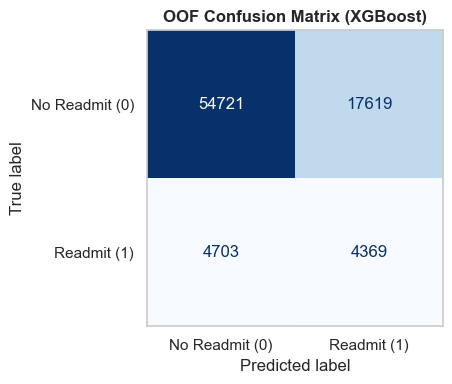


Generating SHAP Summary Plot on Validation Set...


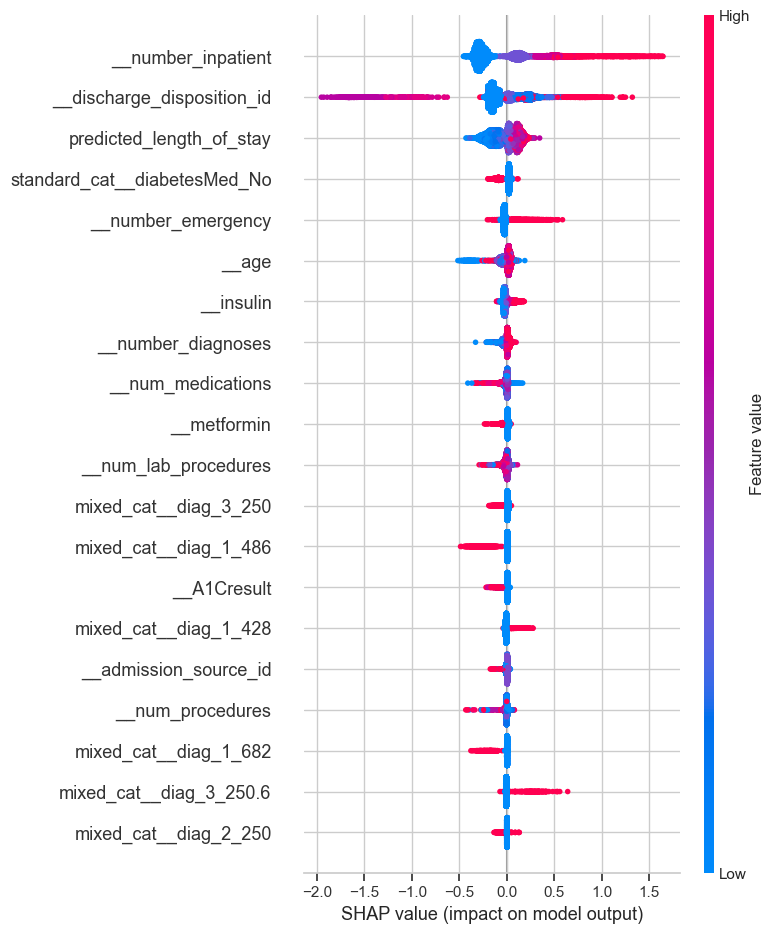

In [30]:
#-----------------------------------------------------------
# XG Boost Classifier Model Predcitons Contd...
#-----------------------------------------------------------

# 3. Out-Of-Fold Metrics & Classification Report
cv_roc_auc = roc_auc_score(y_positive_xg, oof_proba_xg)
cv_pr_auc = average_precision_score(y_positive_xg, oof_proba_xg)
cv_f1 = f1_score(y_positive_xg, oof_pred_xg, pos_label=1)

print("--------------------------------------------------")
print(f"ROC-AUC Score           : {cv_roc_auc:.4f}")
print(f"PR-AUC Score            : {cv_pr_auc:.4f}")
print(f"F1-Score (Positive Class): {cv_f1:.4f}")
print("--------------------------------------------------")
print("\nOut-of-Fold Classification Report:\n")
print(classification_report(y_positive_xg, oof_pred_xg, target_names=['Not Readmitted (0)', 'Readmitted (1)']))
print("---------------------------------------------------")


# 4. Out-Of-Fold Confusion Matrix Plot
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_positive_xg, 
    oof_pred_xg, 
    ax=ax, 
    cmap='Blues', 
    colorbar=False,
    display_labels=['No Readmit (0)', 'Readmit (1)'])
ax.set_title('OOF Confusion Matrix (XGBoost)', fontsize=12, fontweight='bold')
ax.grid(False)
plt.tight_layout()
plt.show()

# 5. SHAP Summary Plot 
print("\nGenerating SHAP Summary Plot on Validation Set...")
X_shap = X_val_fold_xg
explainer = shap.TreeExplainer(xg_models[-1])
shap_values = explainer(X_shap)

plt.figure(figsize=(6, 4))
shap.summary_plot(
    shap_values, 
    X_shap, 
    plot_type="dot", 
    show=True)

------------------------------------------------------------
        TEST SET EVALUATION METRICS (Threshold = 0.5332)
ROC-AUC Score           : 0.6743
PR-AUC Score            : 0.2203
F1-Score (Positive Class): 0.2830
-------------------------------------------------------

Test Set Classification Report:

                    precision    recall  f1-score   support

Not Readmitted (0)       0.92      0.75      0.83     18069
    Readmitted (1)       0.20      0.49      0.28      2285

          accuracy                           0.72     20354
         macro avg       0.56      0.62      0.56     20354
      weighted avg       0.84      0.72      0.77     20354

--------------------------------------------------------------


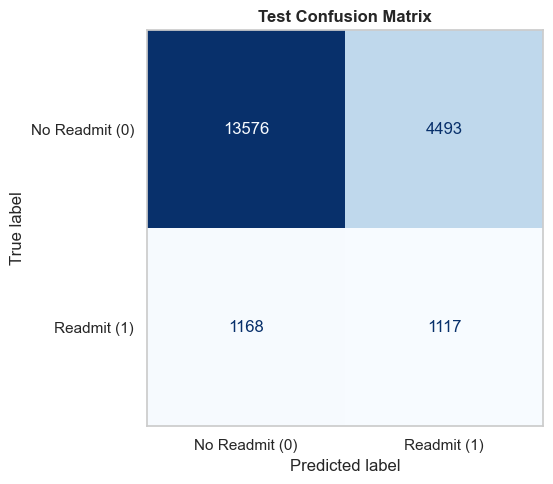

In [31]:
# -------------------------------------------------------------------------
# XGBoost Classifier Contd... : Predcition based on Test Data Set
# -------------------------------------------------------------------------

# 6. Assign model from the K-Fold CV models list (or use ensemble average)
xg_model = xg_models[-1] 

# 7. Test Predictions Using Trained Model & Saved Threshold
y_test_proba_xg = xg_model.predict_proba(X_test)[:, 1]

# 8. Apply the exact threshold learned from training set (Zero Data Leakage)
y_test_pred_xg = (y_test_proba_xg >= best_threshold).astype(int)

# 9. Test Metrics & Classification Report
test_roc_auc = roc_auc_score(y_test_positive_xg, y_test_proba_xg)
test_pr_auc = average_precision_score(y_test_positive_xg, y_test_proba_xg)
test_f1 = f1_score(y_test_positive_xg, y_test_pred_xg, pos_label=1)

print("------------------------------------------------------------")
print(f"        TEST SET EVALUATION METRICS (Threshold = {best_threshold:.4f})")
print("=" * 55)
print(f"ROC-AUC Score           : {test_roc_auc:.4f}")
print(f"PR-AUC Score            : {test_pr_auc:.4f}")
print(f"F1-Score (Positive Class): {test_f1:.4f}")
print("-" * 55)
print("\nTest Set Classification Report:\n")
print(classification_report(y_test_positive_xg, y_test_pred_xg, target_names=['Not Readmitted (0)', 'Readmitted (1)']))
print("--------------------------------------------------------------")

# 10. Test Confusion Matrix Plot ONLY
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_positive_xg, 
    y_test_pred_xg, 
    ax=ax, 
    cmap='Blues', 
    colorbar=False,
    display_labels=['No Readmit (0)', 'Readmit (1)'])
ax.set_title('Test Confusion Matrix', fontsize=12, fontweight='bold')
ax.grid(False)
plt.tight_layout()
plt.show()

## Section 4.4: Selection of Final Approach 

Key Metrics from Hold out Test data predcitions for classification ('Patient Readmission within 30 days')

Model 1 (LightGBM Classifier)
- ROC-AUC Score           : 0.6532
- PR-AUC Score            : 0.2018
- F1-Score (Positive Class): 0.2651
- Accuracy                 :0.65 

Model 2 (XG Boost Classifier):
- ROC-AUC Score           :  0.6743  --> Seperated readmitted vs not admitted accurately
- PR-AUC Score            :  0.2177 --> Good Identification of true readmissions and handled imbalances  
- F1-Score (Positive Class): 0.2813 --> Balanced precision and recall accurately
- Accuracy                 : 0.72 --> Higher accuracy


Why XGBoost better: 
- XGBoost performs well with numeric dense features like predicted length of stays (also predicted in SHAP)
- Avoids overfittings in the presense of higher noisy data

# Conclusions
- The ML Pipeline combination required to predict whether a hospitalised patient with diabetes will be readmitted within 30 days,
  GMM Clustering + with MinMax Scaling + with top 6 PCs ---> To produce patient segment labels
  LightGBM Regression + without feature scaling + with K-fold CV ---> to predict patient length of stay
  XGBoost Classification + without feature scaling ---> To predict whether 'patient gets readmitted within 30 days'   


In [32]:
import json, re

with open("DG4AML_ShaliniGandi_Final.ipynb", "r", encoding="utf-8") as f:
    nb = json.load(f)

text_blocks = []

for cell in nb["cells"]:
    if cell["cell_type"] == "markdown":
        content = "".join(cell["source"])

        # STOP counting if References section appears
        if re.search(r"^\s*#{1,6}\s*references", content, flags=re.I | re.M):
            break

        # remove code blocks
        content = re.sub(r"```.*?```", "", content, flags=re.S)

        # remove headings
        content = re.sub(r"^\s*#{1,6}\s+.*$", "", content, flags=re.M)

        # remove markdown links but keep visible text
        content = re.sub(r"\[([^\]]+)\]\([^)]+\)", r"\1", content)

        # remove markdown symbols
        content = re.sub(r"[>*`_#\[\]\(\)]", " ", content)

        content = re.sub(r"\s+", " ", content).strip()

        if len(content.split()) >= 15:
            text_blocks.append(content)

final_text = " ".join(text_blocks)
word_count = len(final_text.split())

print("Estimated justification word count:", word_count)


Estimated justification word count: 1497


### 6. References
- VanderPlas, J., 2016. Python Data Science Handbook. Chapter 5: Machine Learning. Available at: https://jakevdp.github.io/PythonDataScienceHandbook/.

- James, G., Witten, D., Hastie, T., & Tibshirani, R. (2023). An Introduction to Statistical Learning: with Applications in Python. Springer

- https://machinelearningmastery.com/demystifying-ensemble-methods-boosting-bagging-and-stacking-explained/

- https://www.tutorialspoint.com/python_pandas/python_pandas_concatenation.htm

- Brownlee, J. (2016). Machine Learning Mastery with Python